# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Load and preprocess data
data_path = Path(r"C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit-main/Datasets/Cancer.csv")

# Fallbacks if your current working directory is different
if not data_path.exists():
    for p in [
        Path.cwd() / "Datasets" / "Cancer.csv",
        Path.cwd().parent / "Datasets" / "Cancer.csv",
    ]:
        if p.exists():
            data_path = p
            break

cancer_data = pd.read_csv(data_path)
cancer_data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
cancer_data.replace({'diagnosis': {'M': 1, 'B': 0}}, inplace=True)

# Import SDV libraries
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(cancer_data)

print(f"Loaded from: {data_path}")
print(f"Data shape: {cancer_data.shape}")
print(f"Columns: {list(cancer_data.columns)}")

Loaded from: c:\Users\Gopi.Battineni\OneDrive - University of Limerick\Desktop\FORGE\Synthetic-data_Audit-main\Synthetic_Data_Audit\Datasets\Cancer.csv
Data shape: (569, 31)
Columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


# Generating synthetic data

In [2]:
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = 1000

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(cancer_data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=cancer_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data=cancer_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 31/31 [00:00<00:00, 1855.54it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 464.98it/s]|
Column Shapes Score: 74.03%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:01<00:00, 317.02it/s]|
Column Pair Trends Score: 78.99%

Overall Score (Average): 76.51%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 31/31 [00:00<00:00, 8696.06it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 613.01it/s]|
Column Shapes Score: 65.69%

(2/2) Evaluating Colum

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.943748
1,TVAE,1.0,0.896421
2,CTGAN,1.0,0.765081
3,CopulaGAN,1.0,0.721867



Best model by quality score: GaussianCopula


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,13.063,18.07,82.27,534.0,0.07895,0.04268,0.022739,0.019326,0.1457,...,13.945,25.23,89.44,596.3,0.12997,0.09224,0.102124,0.081370,0.2130,0.07473
1,0,12.903,16.68,83.22,511.3,0.11140,0.13874,0.046816,0.024106,0.2176,...,14.824,25.43,95.36,703.1,0.15198,0.39831,0.219331,0.114531,0.3815,0.10816
2,0,12.144,20.38,79.67,440.2,0.10578,0.15952,0.087810,0.037386,0.2042,...,14.063,31.96,92.47,597.6,0.14872,0.43640,0.252768,0.146417,0.4024,0.10780
3,1,11.171,20.74,71.76,381.8,0.10040,0.08525,0.028174,0.021851,0.1560,...,11.366,27.09,72.87,399.3,0.13801,0.13753,0.049883,0.047761,0.2118,0.07572
4,1,28.110,25.93,188.50,2425.7,0.08694,0.08802,0.138158,0.094686,0.1234,...,36.040,36.42,251.20,3947.7,0.14332,0.26353,0.408867,0.214969,0.1913,0.07765


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 623.43it/s]|
Column Shapes Score: 74.03%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:01<00:00, 422.47it/s]|
Column Pair Trends Score: 78.99%

Overall Score (Average): 76.51%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 471.43it/s]|
Column Shapes Score: 65.69%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:01<00:00, 401.14it/s]|
Column Pair Trends Score: 78.68%

Overall Score (Average): 72.19%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 867.45it/s]|
Column Shapes Score: 87.3%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:01<00:00, 414.66it/s]|
Column Pair Trends Score: 91.98%

Overall Score (Average): 89.64%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 1876.16it/s]|
Column Shapes Score: 93.0%

(2/2) Evaluating Column P

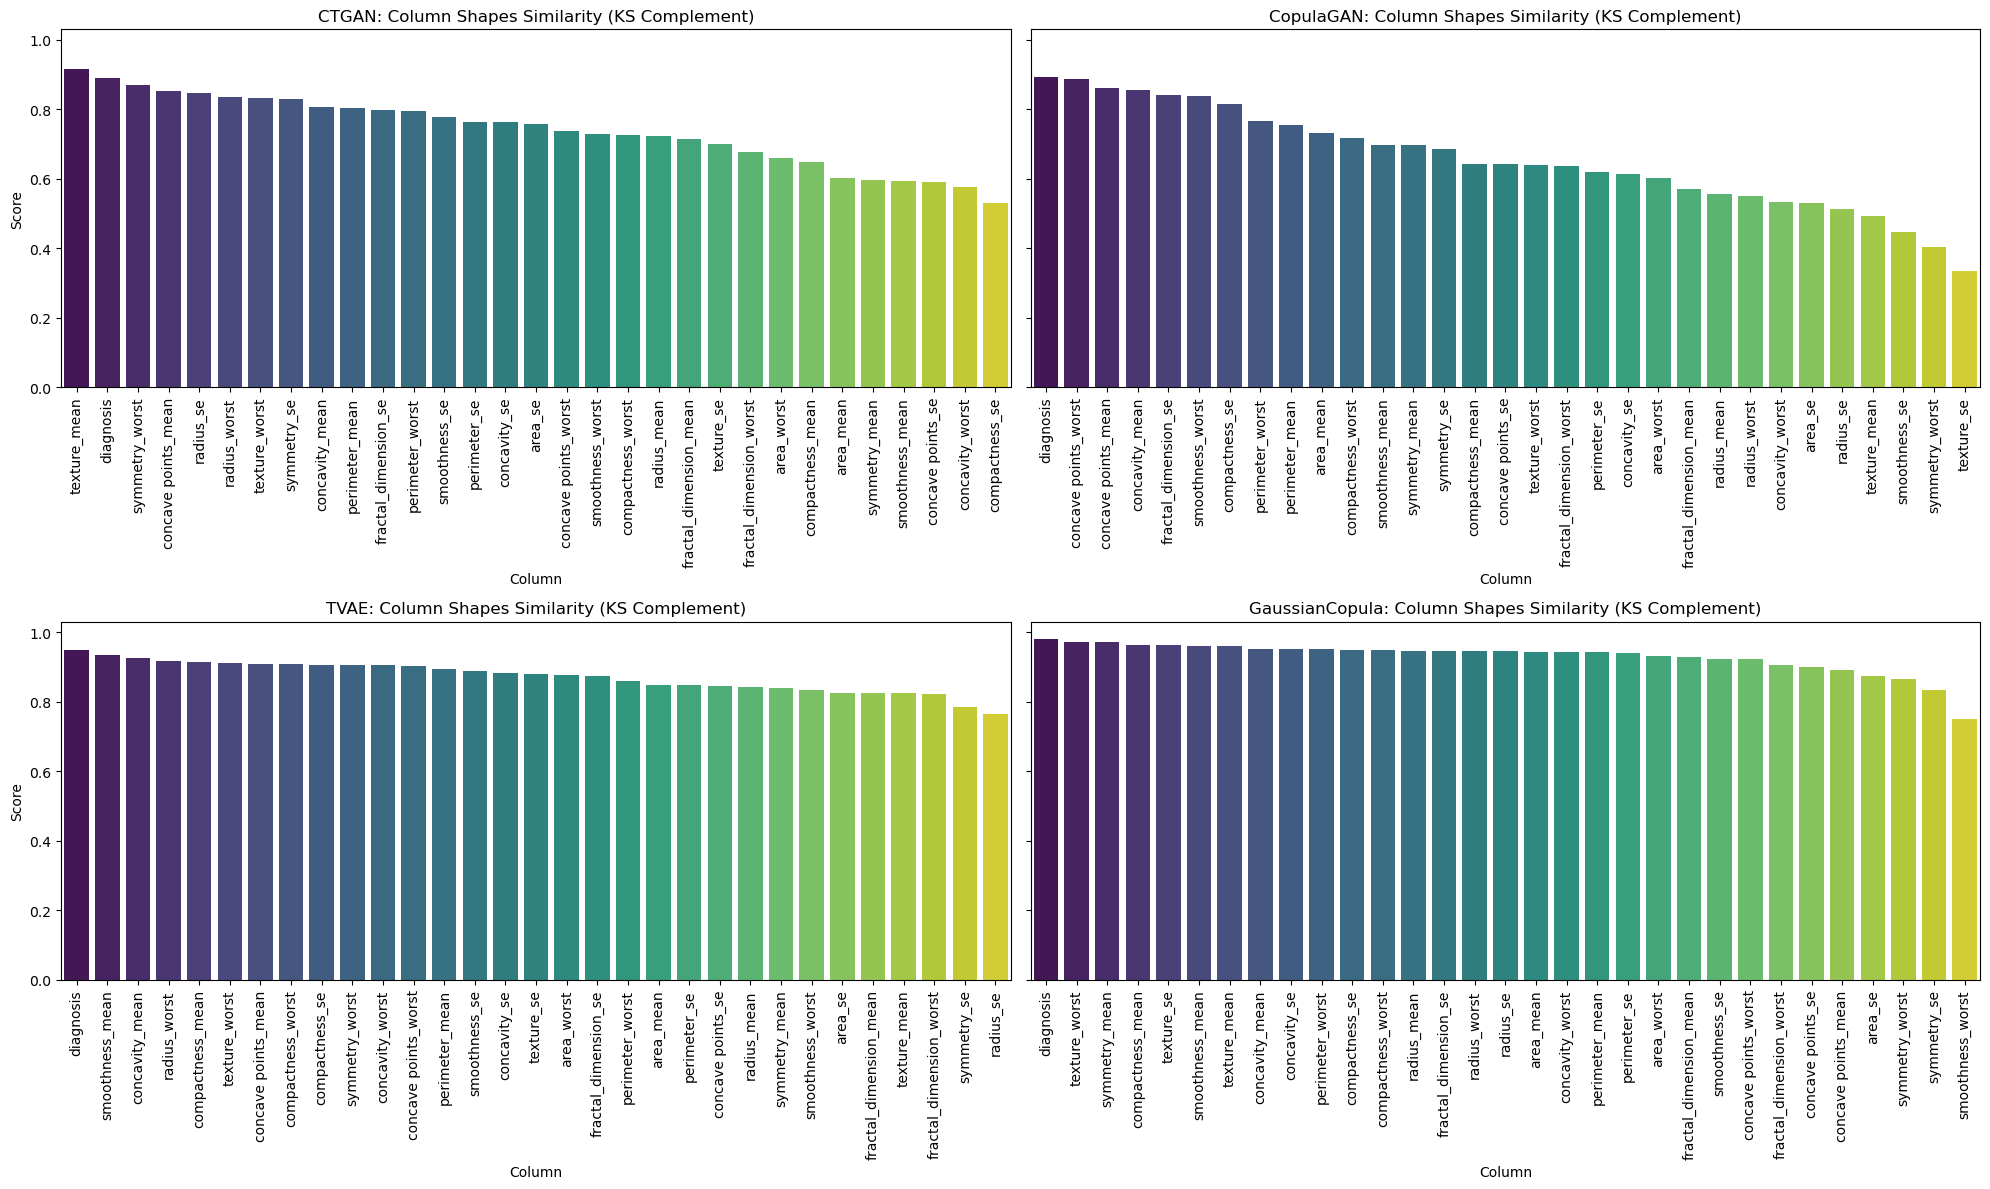

,Column,Metric,Score,Model
0,texture_mean,KSComplement,0.915807,CTGAN
1,diagnosis,TVComplement,0.890583,CTGAN
2,symmetry_worst,KSComplement,0.870930,CTGAN
3,concave points_mean,KSComplement,0.851942,CTGAN
4,radius_se,KSComplement,0.847800,CTGAN
5,radius_worst,KSComplement,0.834810,CTGAN
6,texture_worst,KSComplement,0.833627,CTGAN
7,symmetry_se,KSComplement,0.828694,CTGAN
8,concavity_mean,KSComplement,0.806663,CTGAN
9,perimeter_mean,KSComplement,0.802822,CTGAN


In [3]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assumes these already exist from your previous cell:
# - cancer_data
# - metadata
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
column_shape_details = {}

for model_name in model_order:
    qr = QualityReport()
    qr.generate(
        real_data=cancer_data,
        synthetic_data=synthetic_datasets[model_name],
        metadata=metadata.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


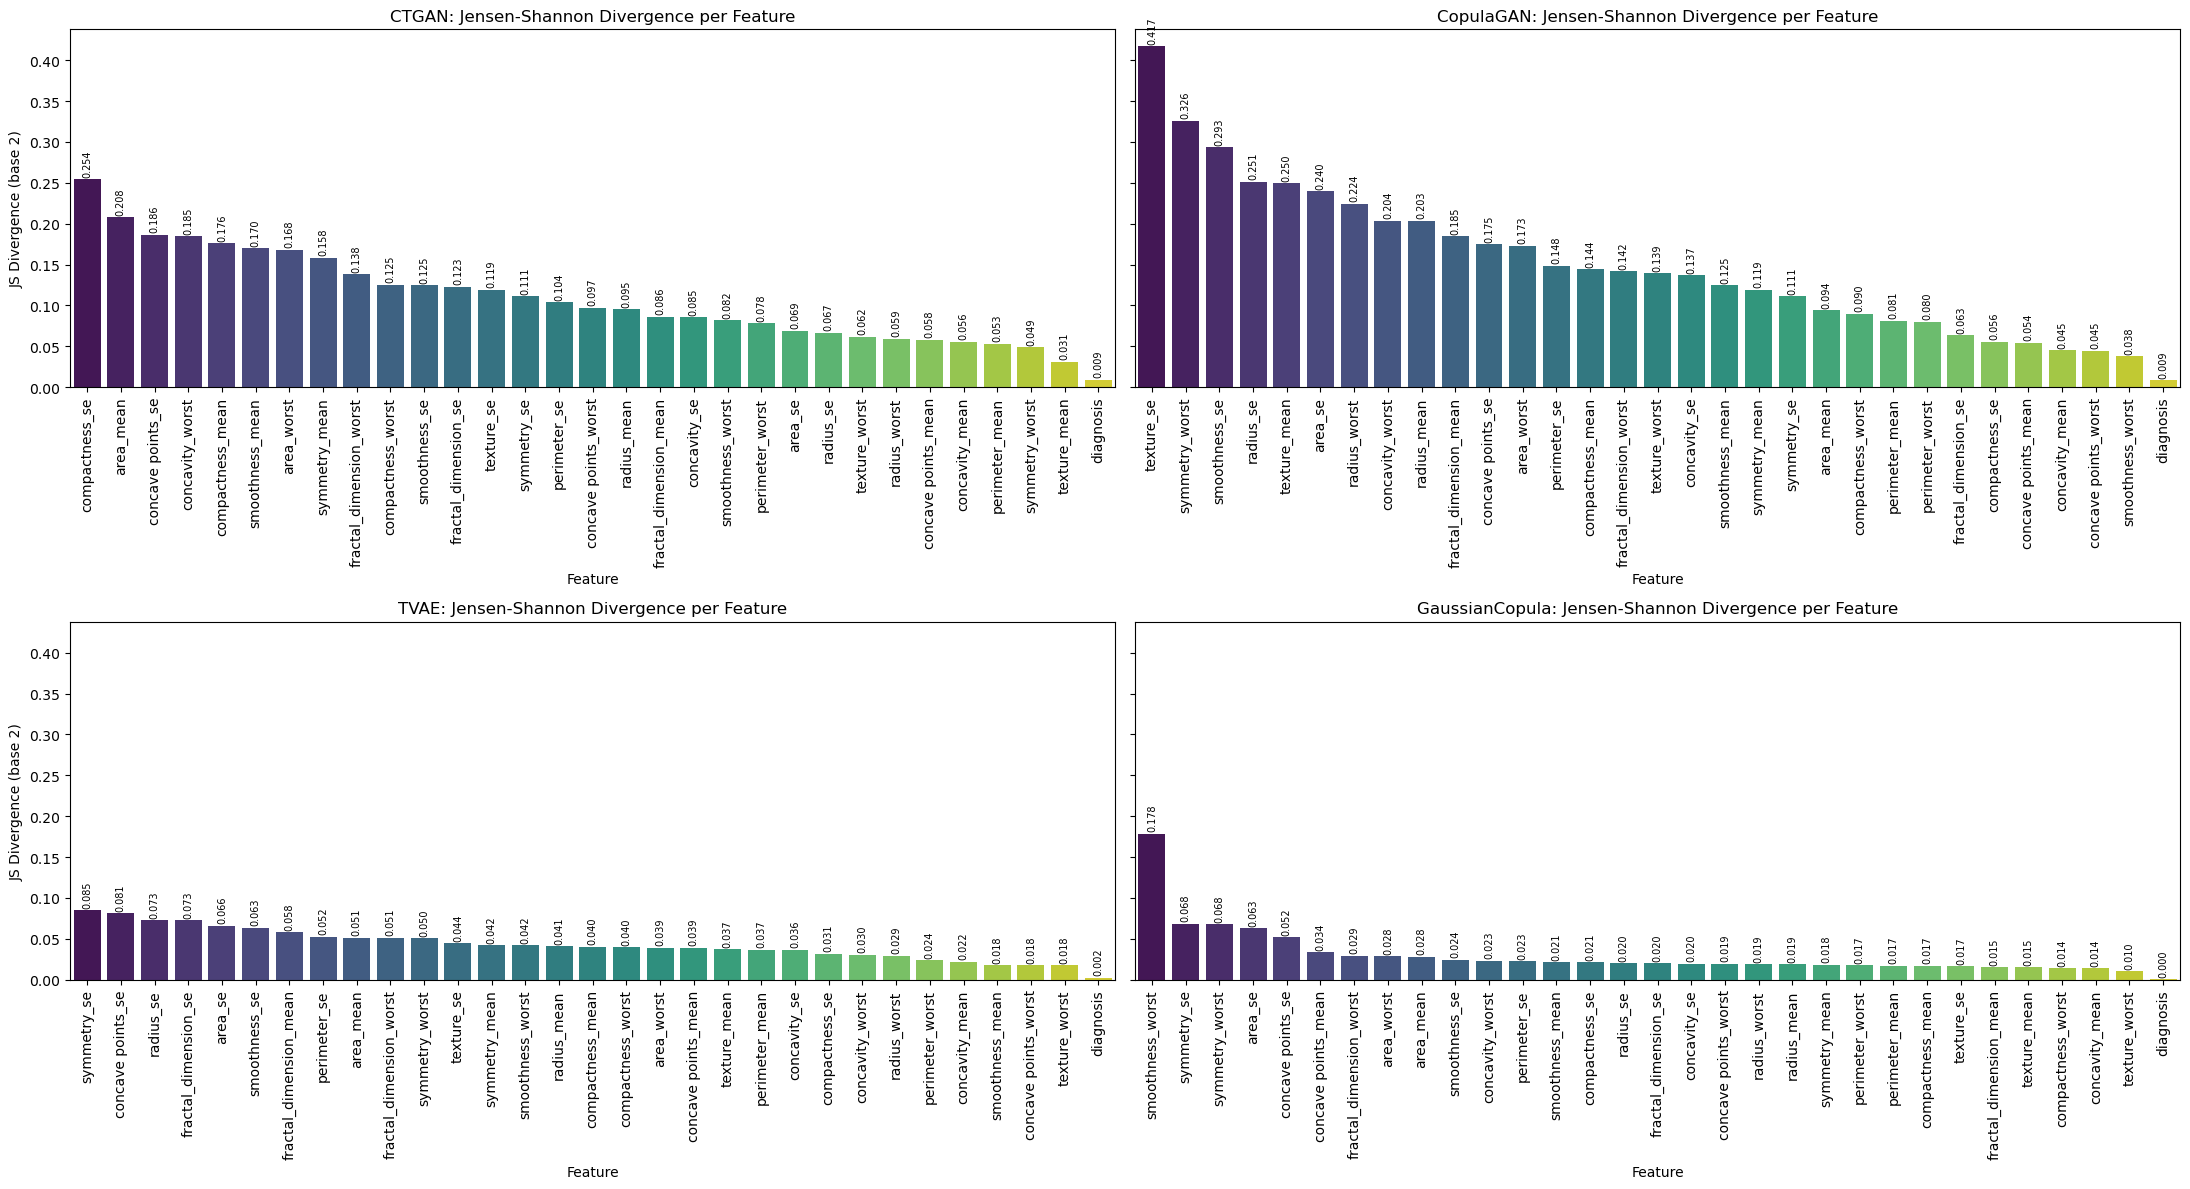

,Feature,JS_Divergence,Model
0,compactness_se,0.254414,CTGAN
1,area_mean,0.207905,CTGAN
2,concave points_se,0.186285,CTGAN
3,concavity_worst,0.184780,CTGAN
4,compactness_mean,0.176116,CTGAN
5,smoothness_mean,0.170237,CTGAN
6,area_worst,0.168326,CTGAN
7,symmetry_mean,0.158445,CTGAN
8,fractal_dimension_worst,0.138026,CTGAN
9,compactness_worst,0.125460,CTGAN


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

# Compute JS divergence for each model
for model_name in model_order:
    js_df = compute_js_divergence(
        cancer_data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    # Add value labels
    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
diagnosis: 0.1094
radius_mean: 0.1150
texture_mean: 0.0261
perimeter_mean: 0.0678
area_mean: 0.0911
smoothness_mean: 0.1215
compactness_mean: 0.1121
concavity_mean: 0.0892
concave points_mean: 0.0788
symmetry_mean: 0.1446
fractal_dimension_mean: 0.0978
radius_se: 0.0328
texture_se: 0.0595
perimeter_se: 0.0275
area_se: 0.0233
smoothness_se: 0.0344
compactness_se: 0.1024
concavity_se: 0.0526
concave points_se: 0.0929
symmetry_se: 0.0430
fractal_dimension_se: 0.0295
radius_worst: 0.0357
texture_worst: 0.0562
perimeter_worst: 0.0518
area_worst: 0.0701
smoothness_worst: 0.0916
compactness_worst: 0.0629
concavity_worst: 0.1259
concave points_worst: 0.1531
symmetry_worst: 0.0371
fractal_dimension_worst: 0.0655

CopulaGAN - Wasserstein Distance:
diagnosis: 0.1074
radius_mean: 0.2199
texture_mean: 0.1548
perimeter_mean: 0.0737
area_mean: 0.1213
smoothness_mean: 0.0926
compactness_mean: 0.0957
concavity_mean: 0.0462
concave points_mean: 0.0805
symmetry_mean: 0.0794

,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.014806,0.011907,0.065988
1,TVAE,0.030417,0.028363,0.051583
2,CTGAN,0.074230,0.067795,0.153142
3,CopulaGAN,0.123656,0.114075,0.317833


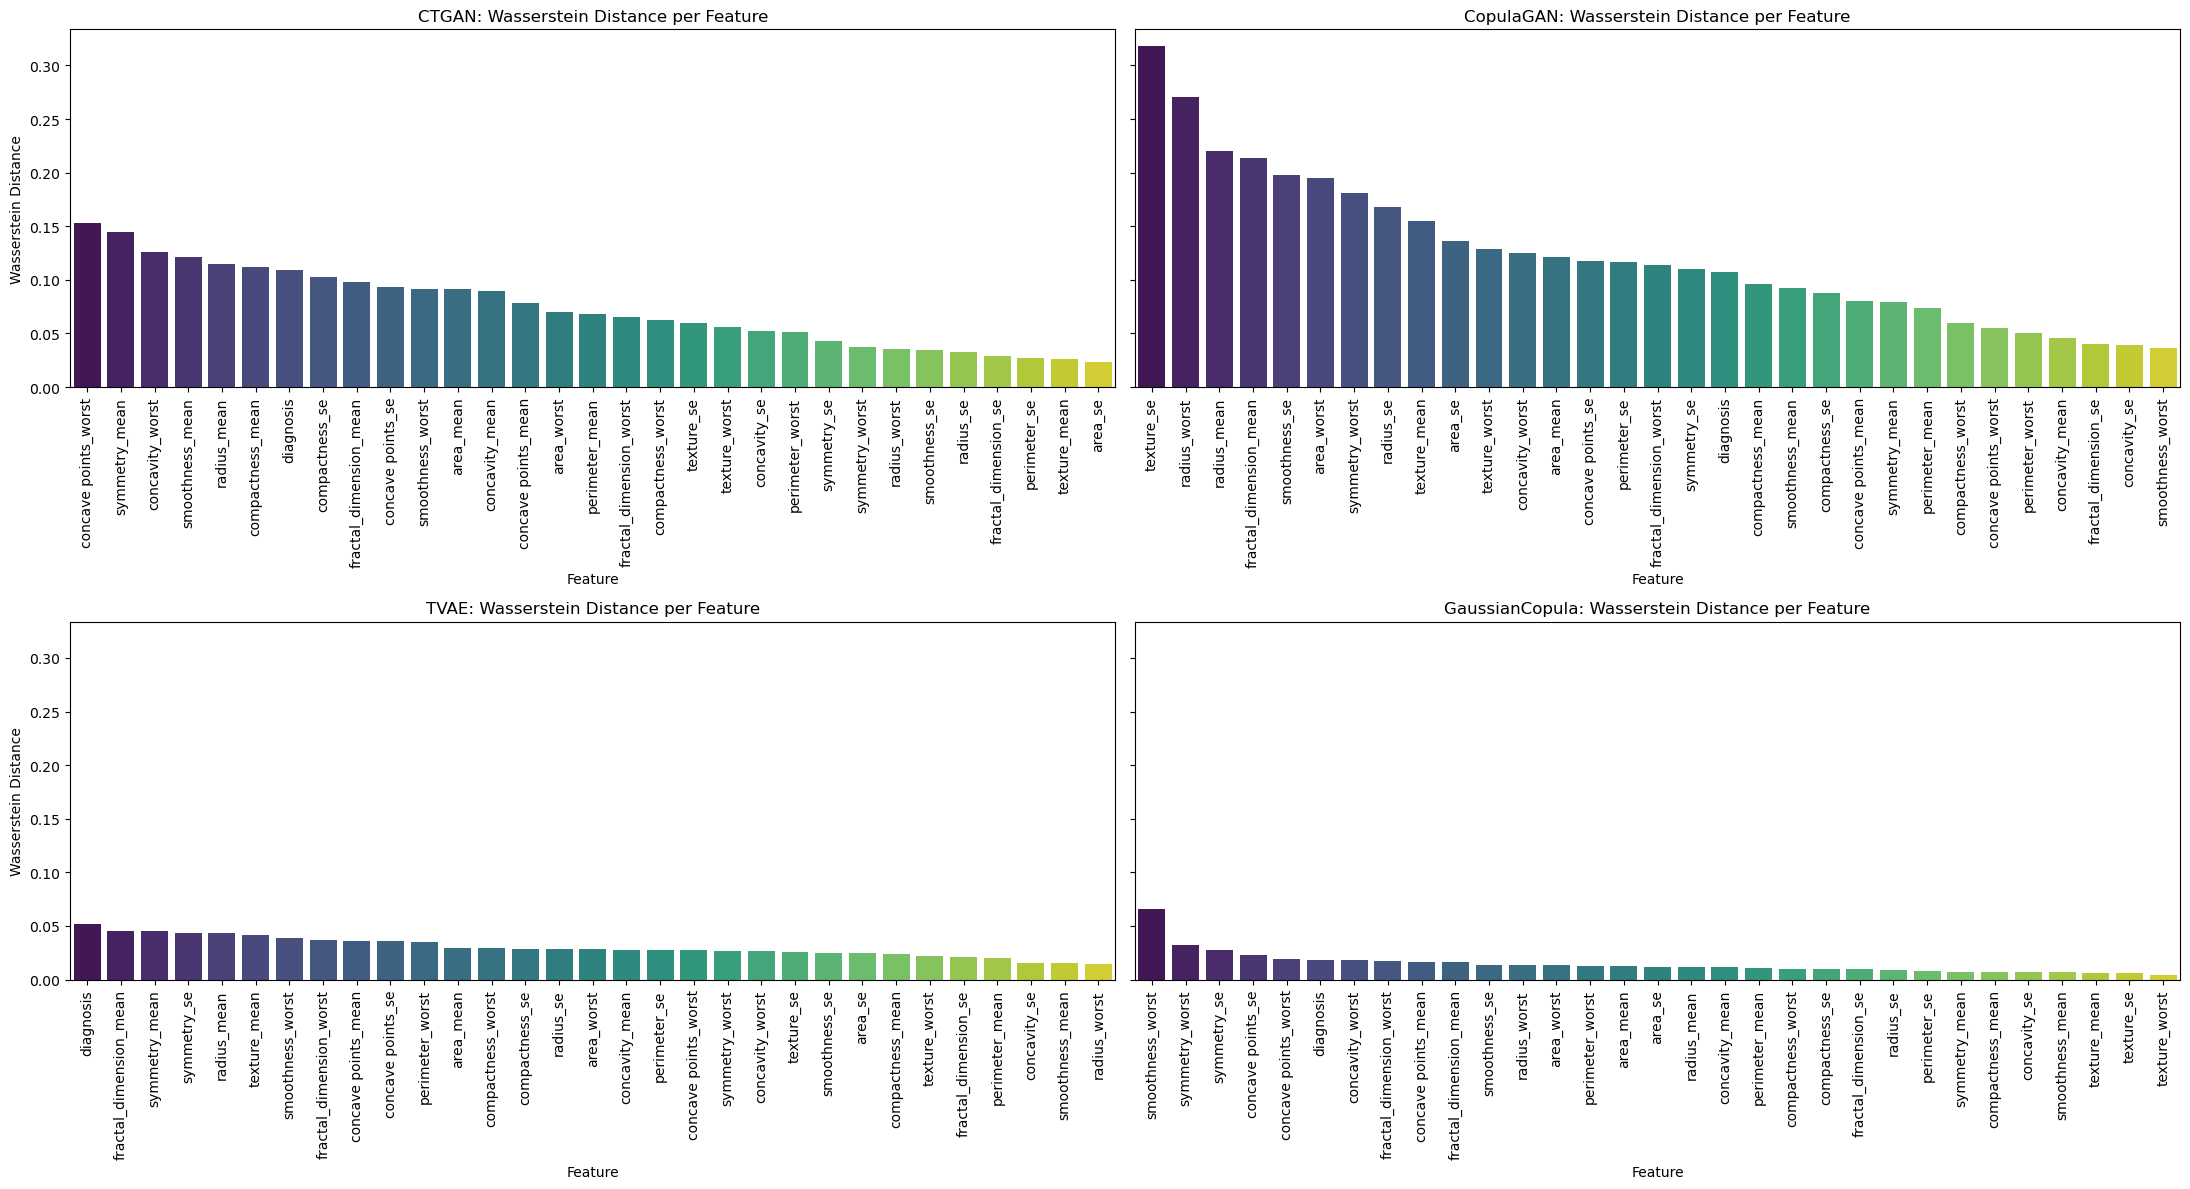

In [6]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - cancer_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(cancer_data),
    columns=cancer_data.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same column order as real data
    synth_df = synth_df[cancer_data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in cancer_data.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [7]:
import numpy as np
import pandas as pd
import gower

# Assumes:
# - cancer_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "diagnosis"

X_real = cancer_data.drop(columns=[target_col], errors="ignore")

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore")

    # Keep same columns/order
    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)

    # Intra-set similarity (1 - Gower distance)
    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    # Cross-set similarity (real vs synthetic only)
    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]  # real x synthetic

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9809, Avg = 0.8528

Intra-set Similarity (Synthetic):
Max = 0.9199, Avg = 0.8044

Cross-set Similarity (Real vs Synthetic):
Max = 0.9398, Avg = 0.8256

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9809, Avg = 0.8528

Intra-set Similarity (Synthetic):
Max = 0.9173, Avg = 0.7748

Cross-set Similarity (Real vs Synthetic):
Max = 0.9131, Avg = 0.7870

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9809, Avg = 0.8528

Intra-set Similarity (Synthetic):
Max = 0.9604, Avg = 0.8385

Cross-set Similarity (Real vs Synthetic):
Max = 0.9728, Avg = 0.8654

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9809, Avg = 0.8528

Intra-set Similarity (Synthetic):
Max = 0.9787, Avg = 0.8238

Cross-set Similarity (Real vs Synthetic):
Max = 0.9820, Avg = 0.8519


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,0.980939,0.85279,0.919858,0.804441,0.939805,0.825575
1,CopulaGAN,0.980939,0.85279,0.917311,0.774793,0.913137,0.787046
2,TVAE,0.980939,0.85279,0.960448,0.838526,0.972831,0.865425
3,GaussianCopula,0.980939,0.85279,0.978746,0.823819,0.981992,0.851888


### 1.5 t-SNE Visualization


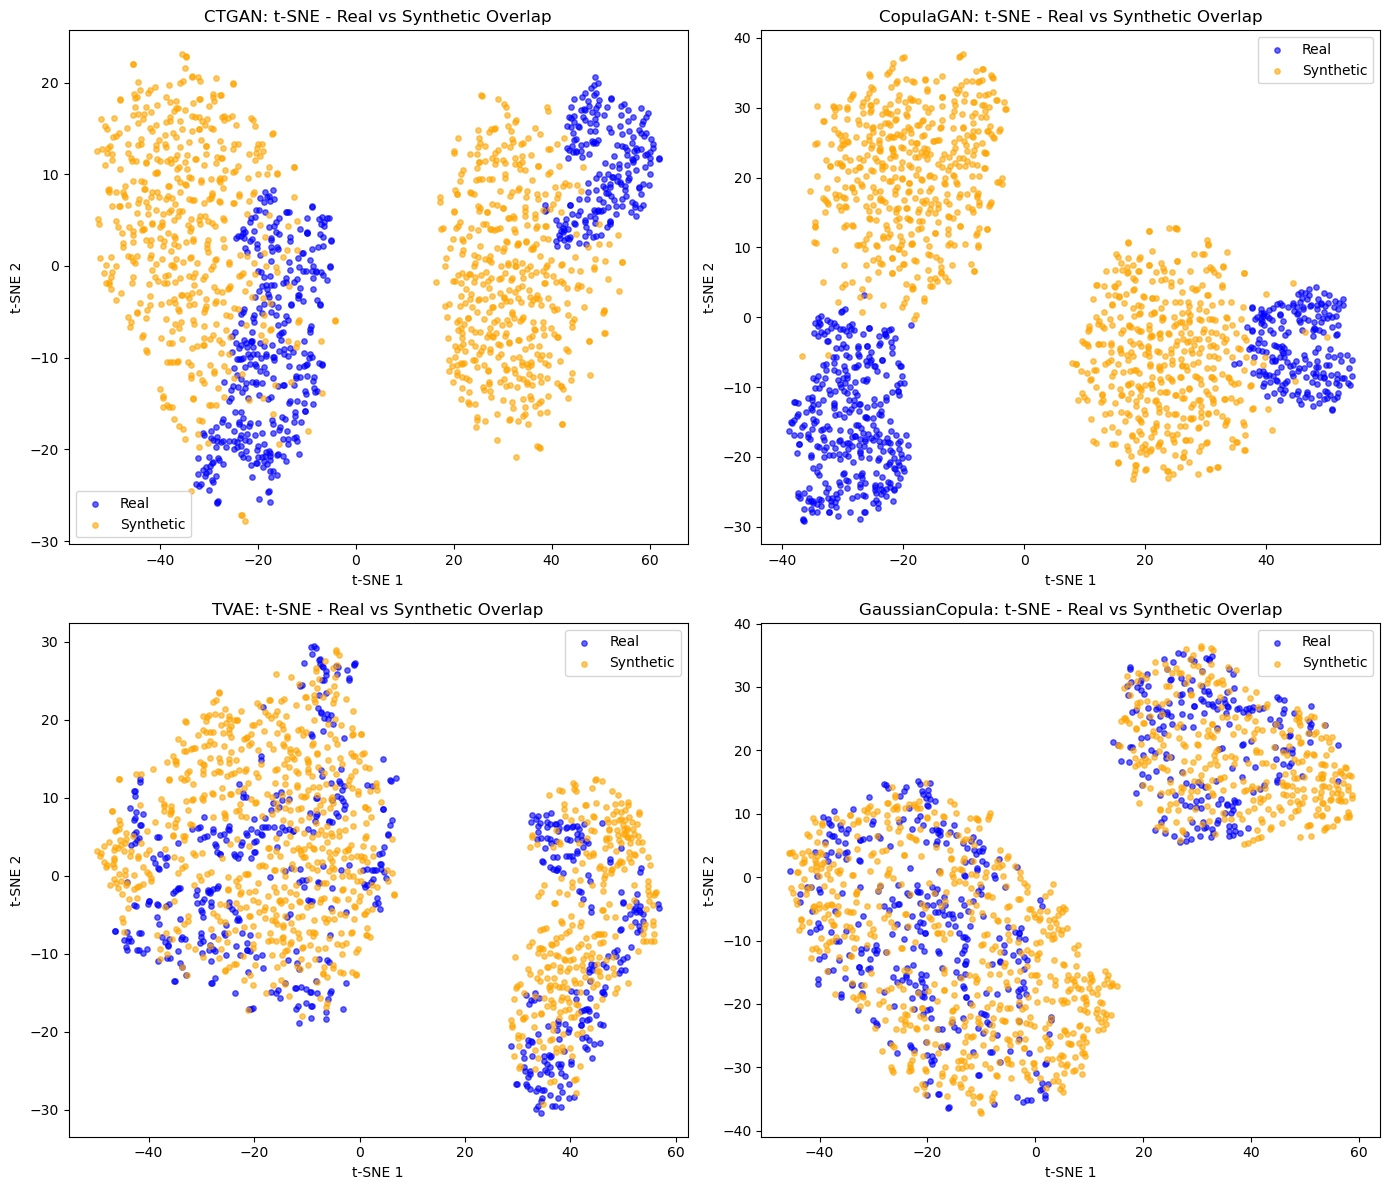

In [8]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - cancer_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(cancer_data),
    columns=cancer_data.columns
)

# Create 2x2 t-SNE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][cancer_data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Assumes:
# - cancer_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "diagnosis"

# Real features (exclude target)
real_features = cancer_data.drop(columns=[target_col], errors="ignore")

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Lower MMD is better
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.1425
CopulaGAN - MMD score: 0.3416
TVAE - MMD score: 0.0202
GaussianCopula - MMD score: 0.0039

MMD comparison (lower is better):


,Model,MMD_Score
0,GaussianCopula,0.003901
1,TVAE,0.020162
2,CTGAN,0.142486
3,CopulaGAN,0.341616


### 1.7 Cosine Similarity


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Assumes:
# - cancer_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "diagnosis"

real_features = cancer_data.drop(columns=[target_col], errors="ignore")
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    # Scale using real data stats (same pattern as your MMD cell)
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0073
Maximum cosine similarity: 0.8273

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0427
Maximum cosine similarity: 0.7743

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0432
Maximum cosine similarity: 0.9559

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0128
Maximum cosine similarity: 0.9734

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.043196,0.955853
1,GaussianCopula,0.012774,0.973417
2,CTGAN,0.007301,0.827296
3,CopulaGAN,-0.042749,0.774291


### 1.8 Nearest Neighbours 


In [11]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "diagnosis"

real_features = cancer_data.drop(columns=[target_col], errors="ignore")
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    # Scale using real data statistics
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Nearest-neighbor privacy check: Synthetic -> Real
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)
    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 6.2643
Minimum NN Distance (Synthetic -> Real): 3.0299
5th Percentile NN Distance: 4.6604

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 8.7546
Minimum NN Distance (Synthetic -> Real): 4.6518
5th Percentile NN Distance: 6.4423

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.7861
Minimum NN Distance (Synthetic -> Real): 1.3236
5th Percentile NN Distance: 1.8765

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.7229
Minimum NN Distance (Synthetic -> Real): 0.9527
5th Percentile NN Distance: 1.6405

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,CopulaGAN,8.754585,4.651801,6.442333
1,CTGAN,6.264304,3.029884,4.660442
2,TVAE,2.786137,1.323552,1.876507
3,GaussianCopula,2.722936,0.952729,1.640489


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,22.139785,16.473968,20.111976
1,CopulaGAN,43.617757,31.169478,46.802060
2,TVAE,9.333224,6.516332,24.693156
3,GaussianCopula,1.140859,0.892742,9.024199


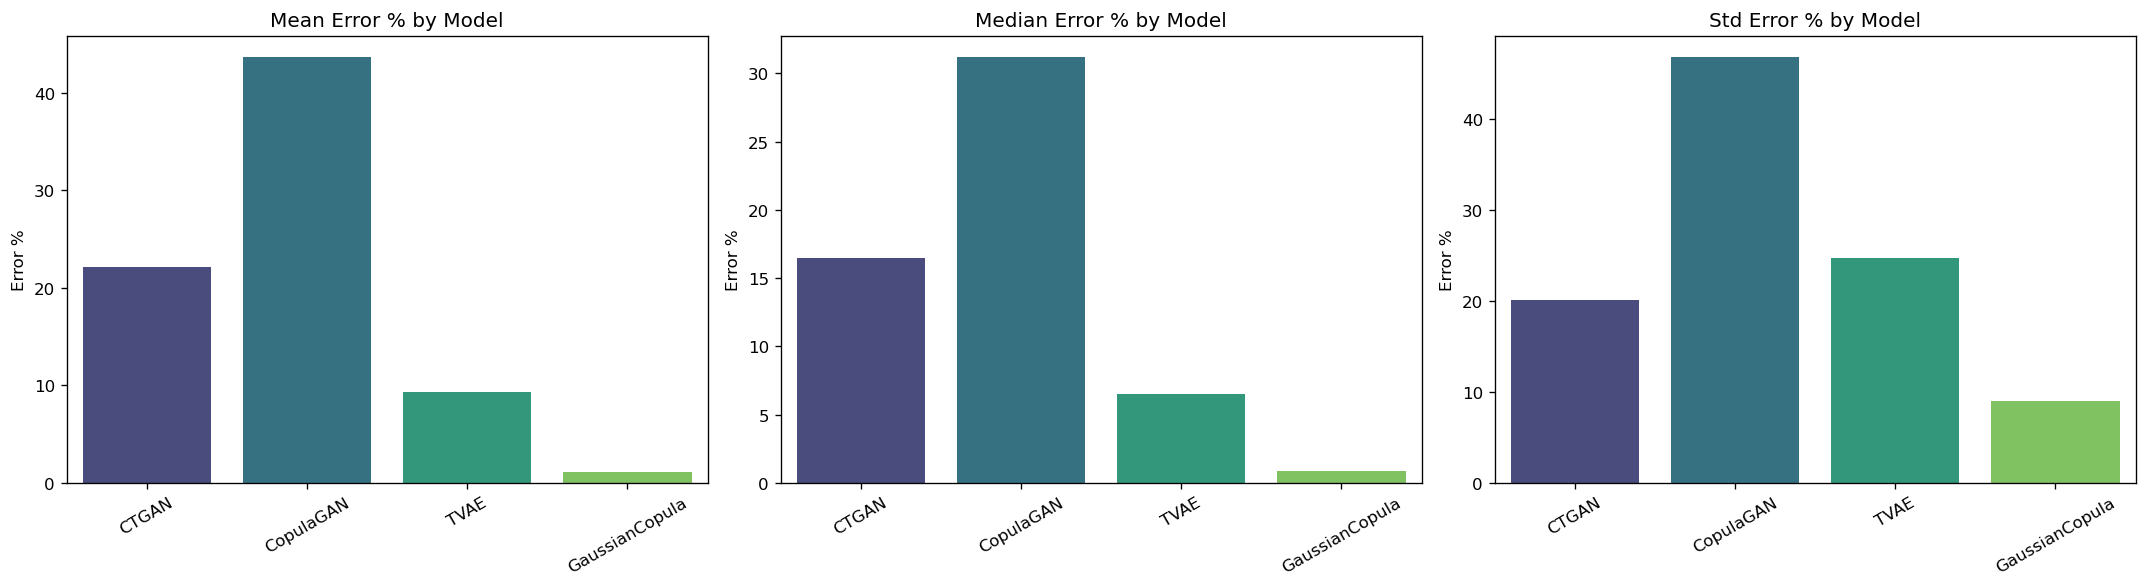

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = cancer_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "diagnosis" in num_cols:
    num_cols.remove("diagnosis")

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


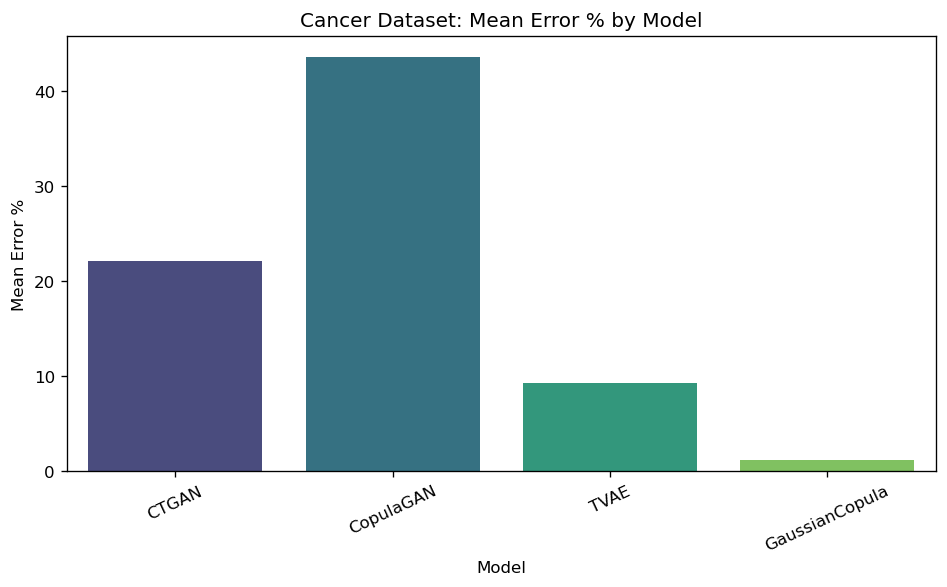

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Cancer Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

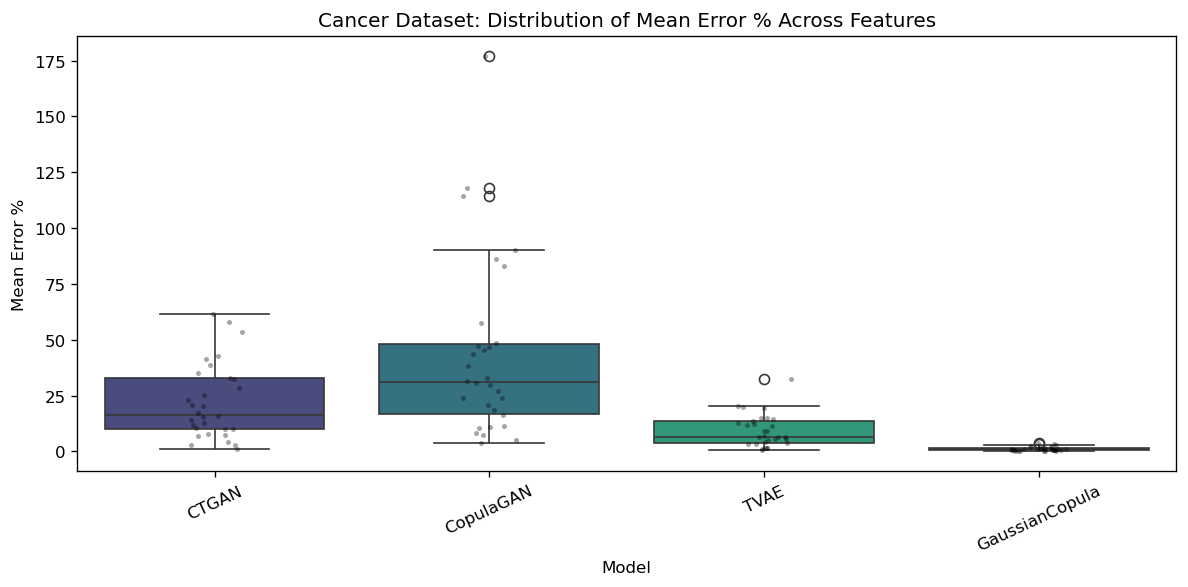

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Cancer Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

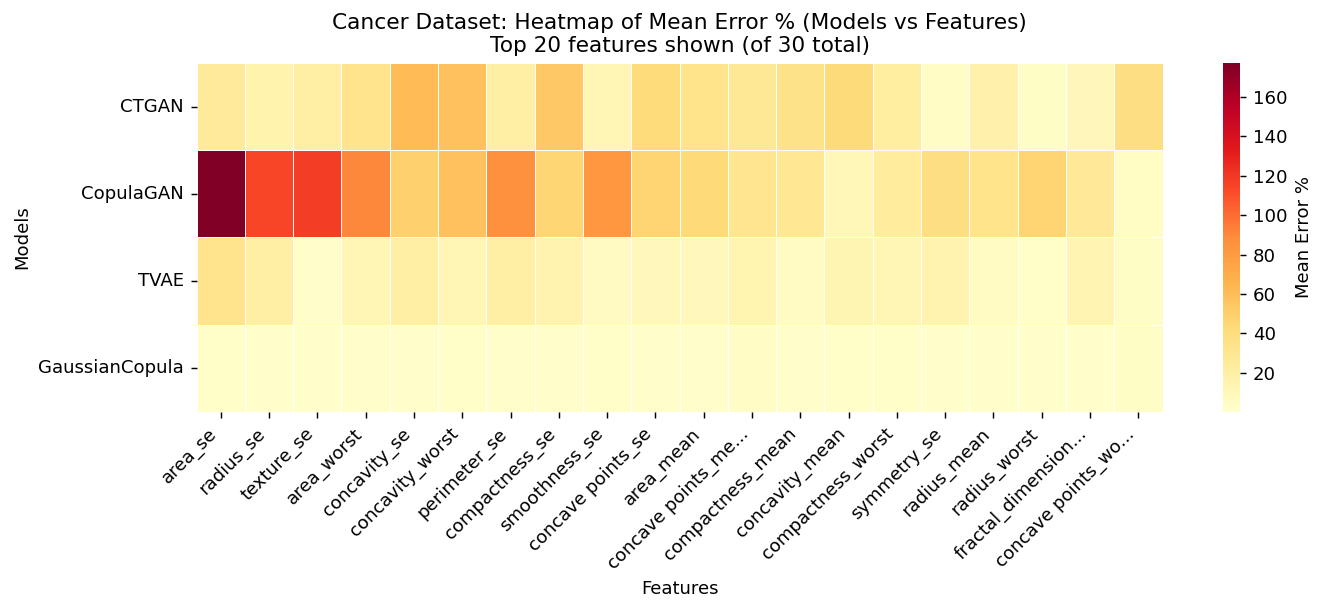

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Cancer Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [16]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_cancer(real_df, synth_df, target='diagnosis'):
    """Compute bivariate quality metrics for cancer data."""
    num_cols = [c for c in real_df.columns if c != target]
    
    # Min-Max scaling on numeric columns
    scaler = MinMaxScaler()
    
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    
    # Fit on real, transform both real and synthetic
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    
    results_corr = []
    results_target = []

    # Numeric-to-numeric: Δ-correlation
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            'var_a': a,
            'var_b': b,
            'delta_corr': abs(r_corr - s_corr)
        })
    
    # Numeric-to-target: Δ-Wasserstein between classes
    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]
        
        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
    
    return corr_df, target_df


In [17]:
# Assumes:
# - cancer_data
# - synthetic_datasets dict with keys: "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"
# - bivariate_quality_cancer(real_df, synth_df) is already defined

import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = cancer_data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]  # align column order

    corr_results, target_results = bivariate_quality_cancer(
        real_df=real_df,
        synth_df=synth_df
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by diagnosis class:")
    display(target_results.head(10))
    print("=" * 60)

    # Optional compact summary if score/diff column exists
    corr_metric_col = next((c for c in ["AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col else None,
    })

# Optional model-level summary table (lower differences are better)
summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
76,perimeter_mean,perimeter_worst,1.004611
1,radius_mean,perimeter_mean,1.001397
102,area_mean,perimeter_worst,0.990198
247,radius_se,area_se,0.989105
282,perimeter_se,area_se,0.981333
246,radius_se,perimeter_se,0.981251
201,concave points_mean,concave points_worst,0.979156
74,perimeter_mean,radius_worst,0.978227
2,radius_mean,area_mean,0.971102
407,perimeter_worst,area_worst,0.970439


CTGAN - Features that differ most by diagnosis class:


,feature,delta_wasserstein
7,concave points_mean,0.278730
6,concavity_mean,0.231237
27,concave points_worst,0.226819
20,radius_worst,0.222396
22,perimeter_worst,0.218256
2,perimeter_mean,0.207592
26,concavity_worst,0.201549
23,area_worst,0.191226
5,compactness_mean,0.182101
3,area_mean,0.179449



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
190,concave points_mean,concavity_se,0.232499
354,concavity_se,concave points_worst,0.227887
357,concave points_se,symmetry_se,0.227422
365,concave points_se,concavity_worst,0.221213
184,concave points_mean,radius_se,0.218750
170,concavity_mean,symmetry_se,0.217769
162,concavity_mean,radius_se,0.209228
352,concavity_se,compactness_worst,0.205069
191,concave points_mean,concave points_se,0.204101
345,concavity_se,symmetry_se,0.183836


GaussianCopula - Features that differ most by diagnosis class:


,feature,delta_wasserstein
27,concave points_worst,0.200707
7,concave points_mean,0.160503
6,concavity_mean,0.142983
20,radius_worst,0.122645
26,concavity_worst,0.118106
22,perimeter_worst,0.118090
2,perimeter_mean,0.106251
0,radius_mean,0.103351
24,smoothness_worst,0.101213
23,area_worst,0.096601


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,None,None,None,None
1,CopulaGAN,None,None,None,None
2,TVAE,None,None,None,None
3,GaussianCopula,None,None,None,None


### 3 Multivariate Analysis


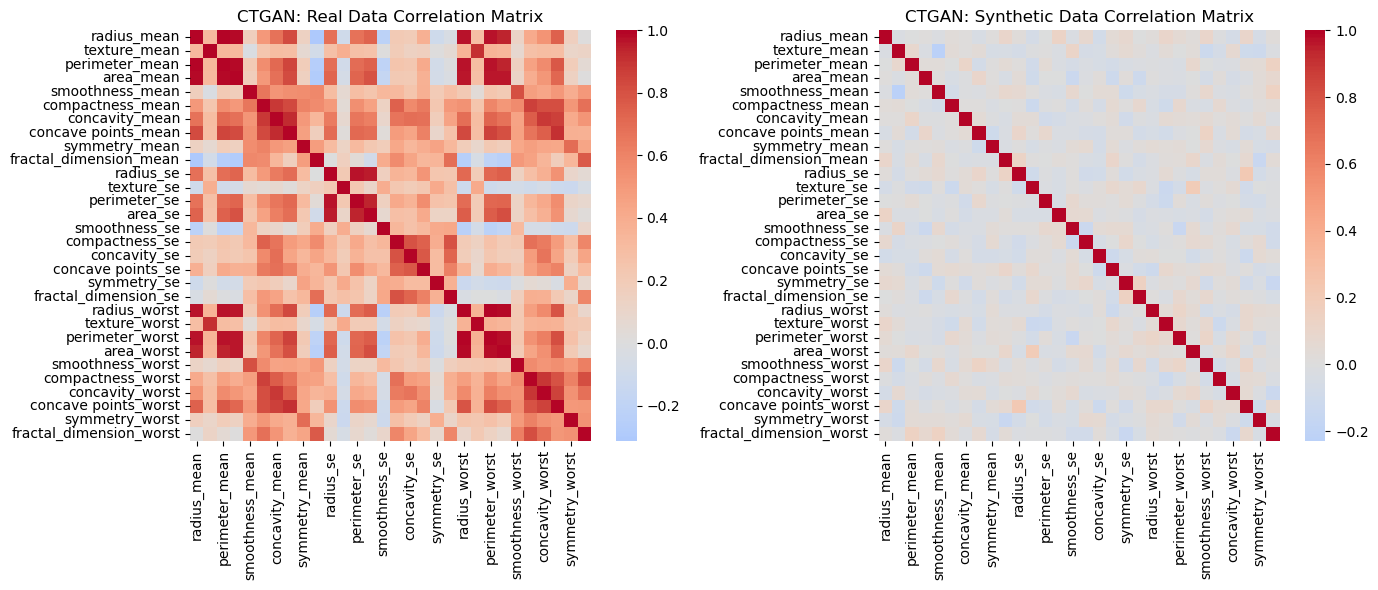

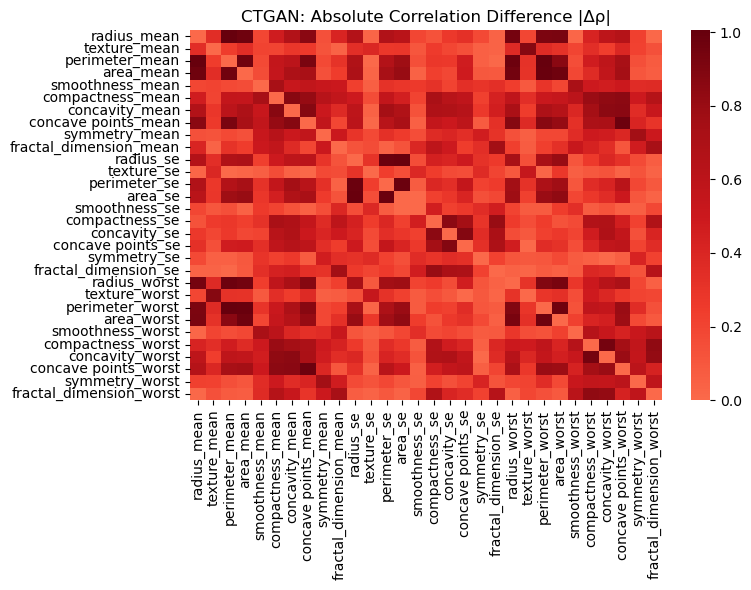

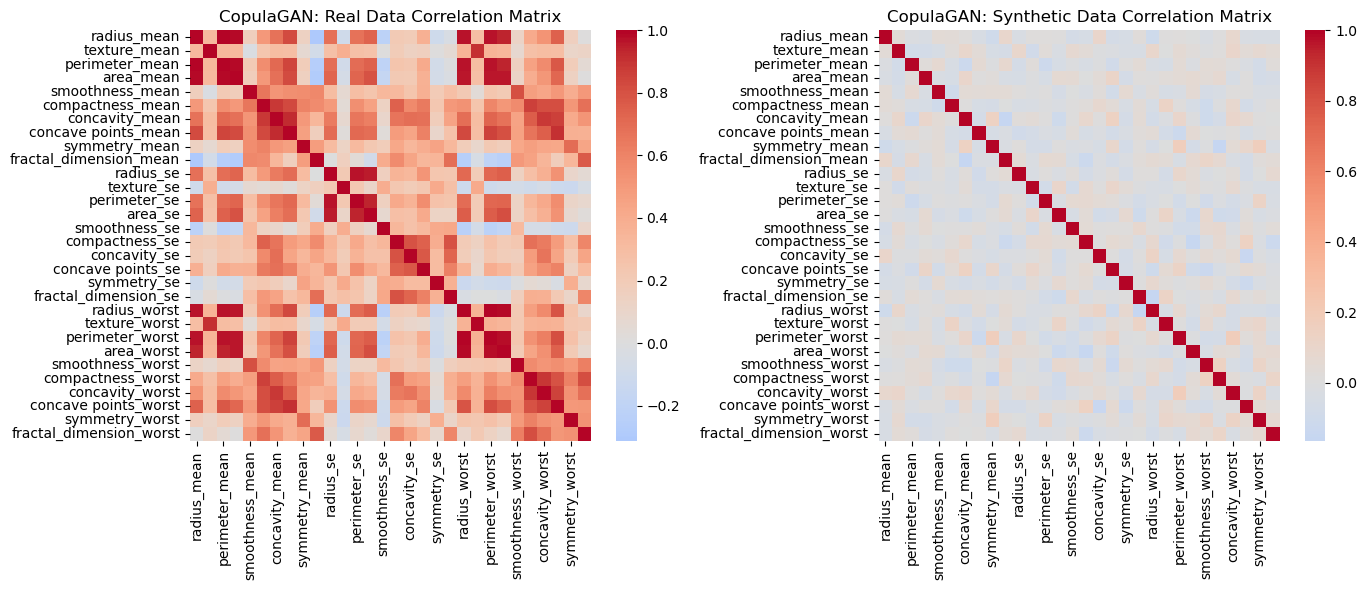

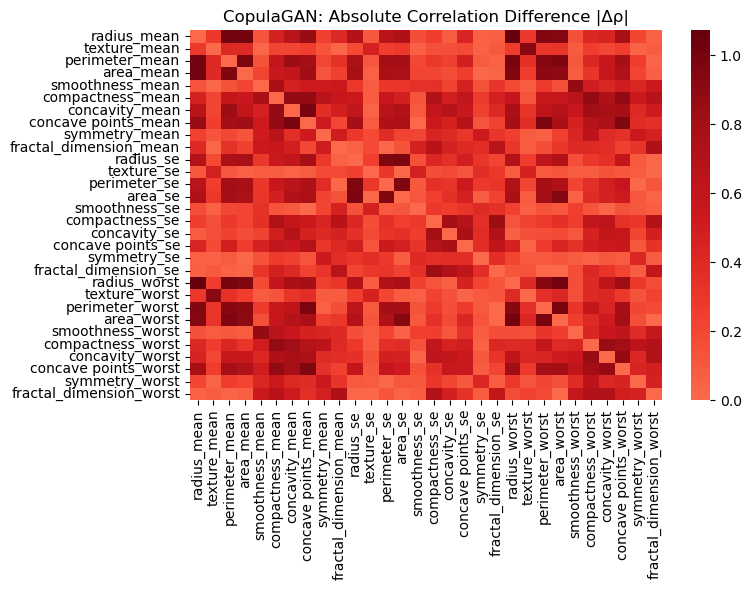

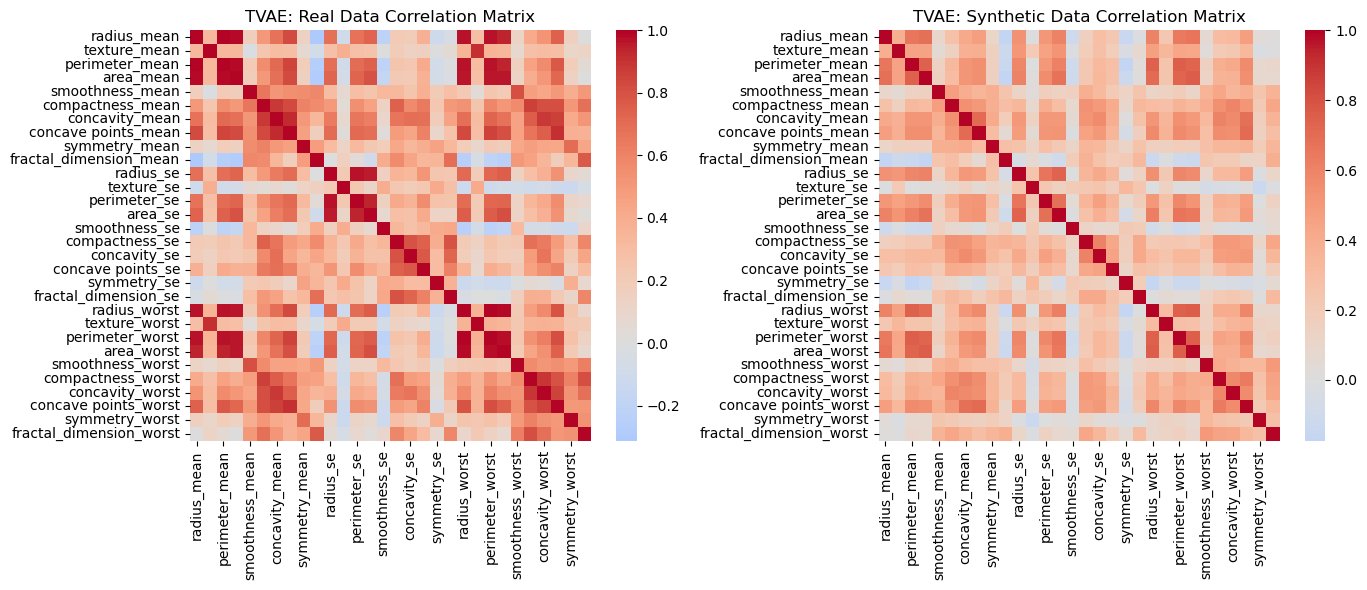

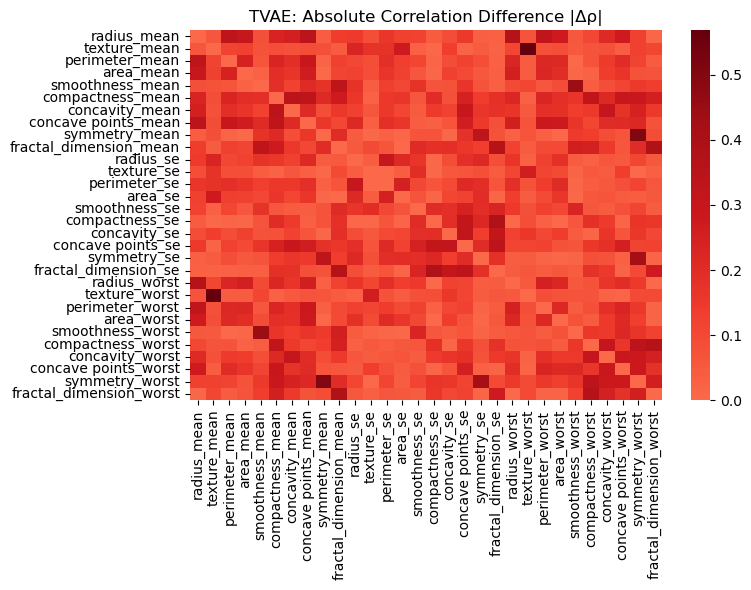

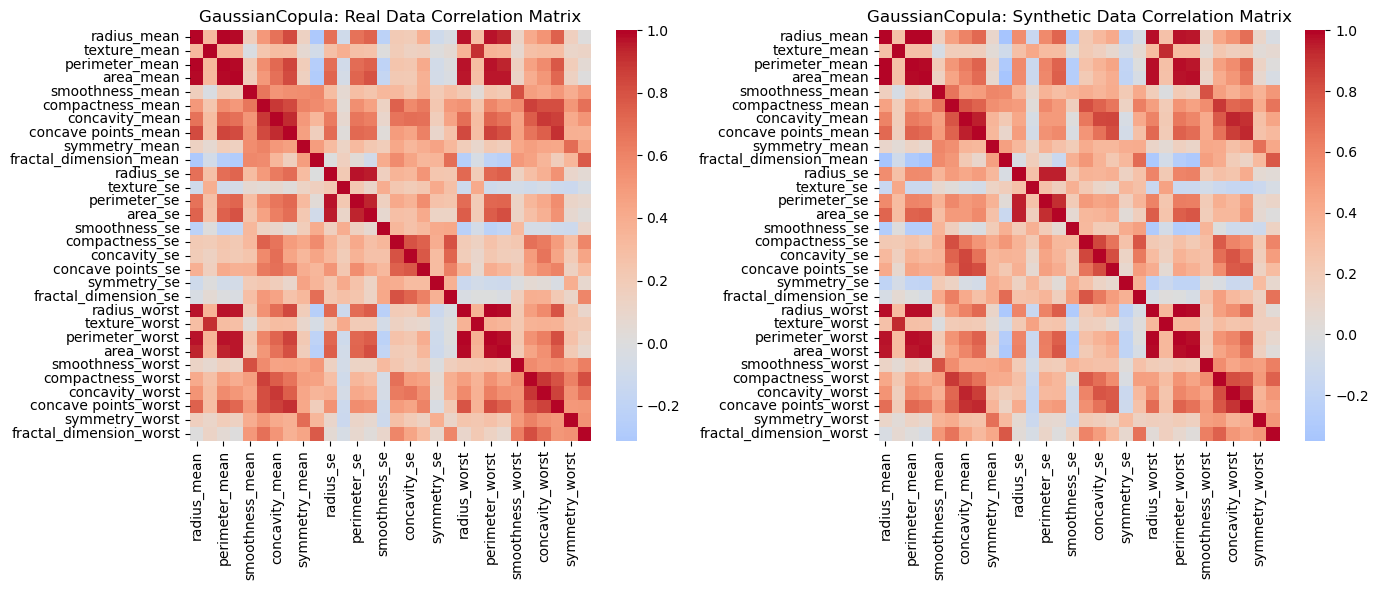

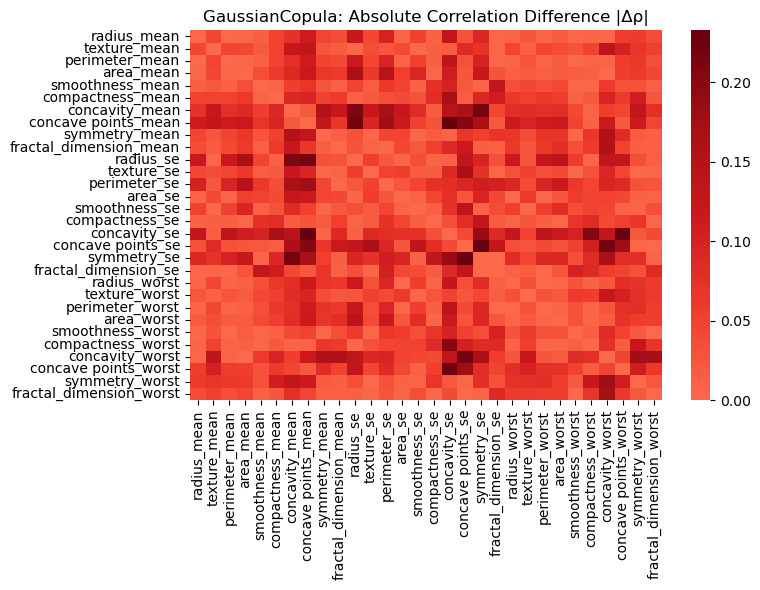

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes:
# - cancer_data
# - synthetic_datasets dict with keys: "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = cancer_data.copy()
num_cols = [c for c in real_df.columns if c != "diagnosis"]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]  # align columns/order
    synth_corr = synth_df[num_cols].corr()

    # 1) Real vs Synthetic correlation matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # 2) Absolute correlation difference heatmap
    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.087208


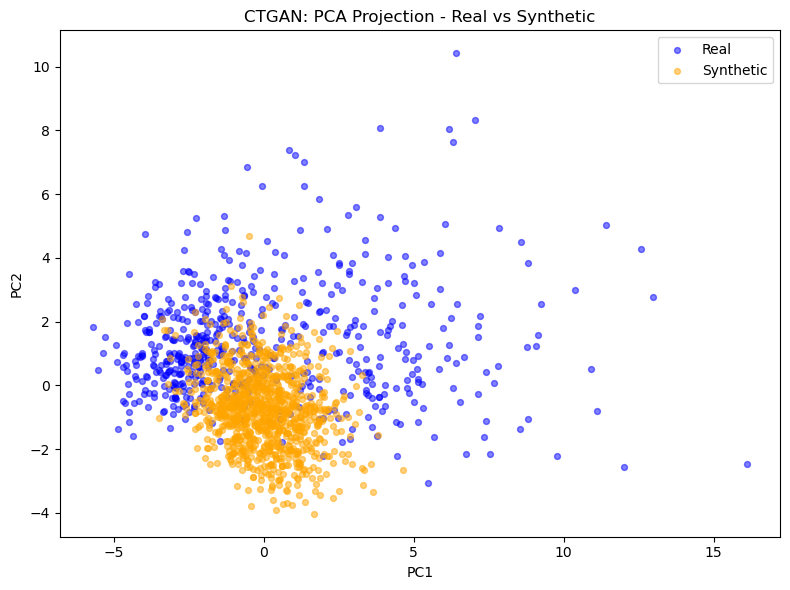

CTGAN - Two-Sample Classifier Accuracy: 0.9958

CopulaGAN - Global MMD (RBF): 0.210474


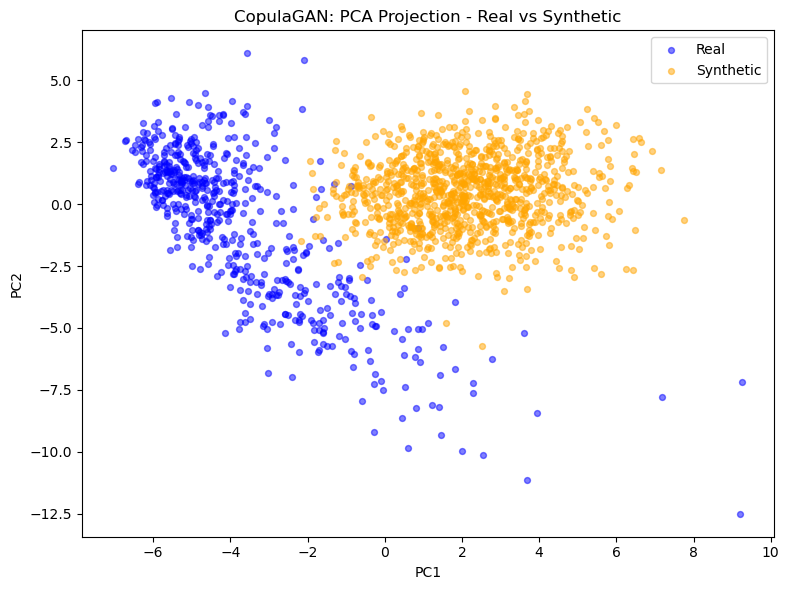

CopulaGAN - Two-Sample Classifier Accuracy: 0.9958

TVAE - Global MMD (RBF): 0.018341


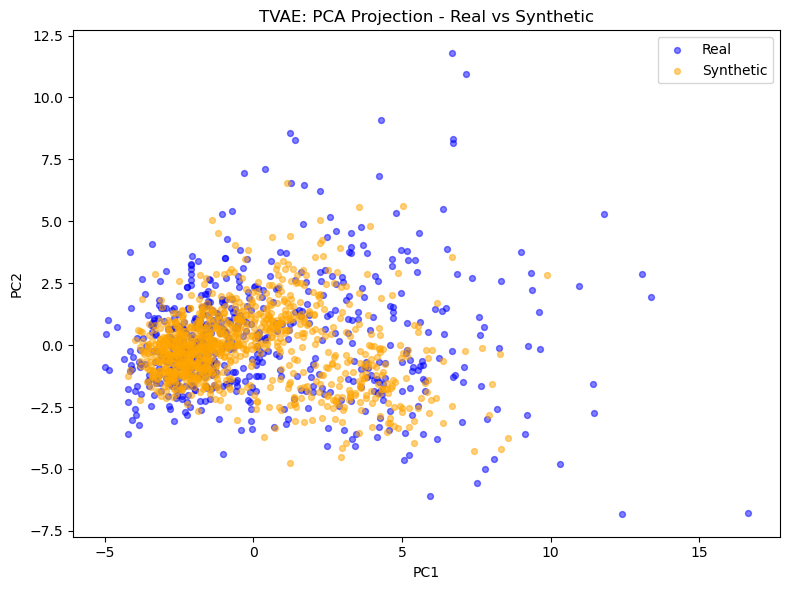

TVAE - Two-Sample Classifier Accuracy: 0.8641

GaussianCopula - Global MMD (RBF): 0.001456


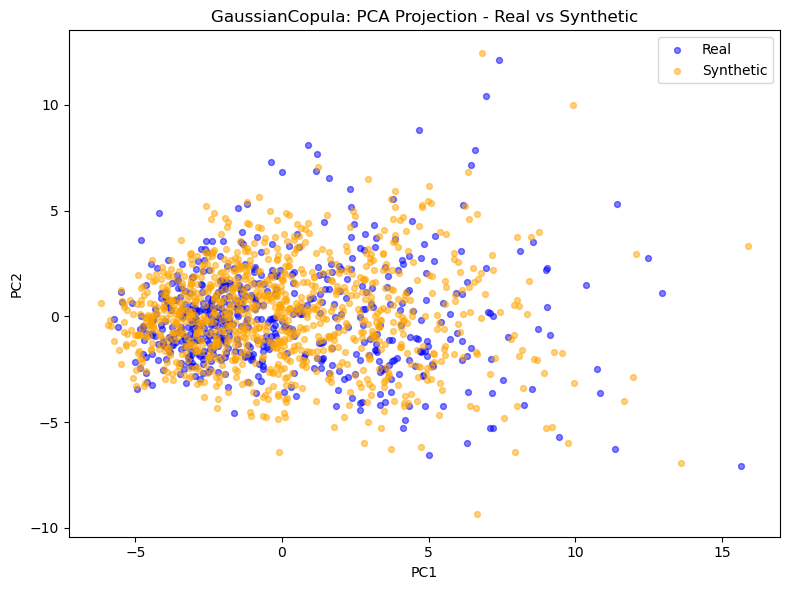

GaussianCopula - Two-Sample Classifier Accuracy: 0.8110

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,GaussianCopula,0.001456,0.811040
1,TVAE,0.018341,0.864119
2,CTGAN,0.087208,0.995754
3,CopulaGAN,0.210474,0.995754


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assumes:
# - cancer_data
# - synthetic_datasets dict with keys: "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2))
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "diagnosis"

X_real_df = cancer_data.drop(columns=[target_col], errors="ignore")
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = X_synth_df[common_cols].values

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # 1) Global MMD (RBF)
    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    # 2) PCA visualization
    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Classifier Two-Sample Test (C2ST)
    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

# Summary table
results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers 

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_models(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    # Split TRAIN df -> (train part only)  (we don’t need train_df's test split)
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    # Split TEST df -> (test part only)
    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    # Scale using TRAIN statistics only
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)

        y_pred = clf.predict(X_test_s)

        # AUC needs probabilities (or decision_function); handle both safely
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            # convert to 0-1-ish range (not perfect prob, but works for AUC)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)

        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

In [22]:
import pandas as pd

label_col = "diagnosis"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=cancer_data,
    test_df=cancer_data,
    label="diagnosis",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=cancer_data,
        label="diagnosis",
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (combined_comparison
           .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
           .mean()
           .sort_values("AUC_Drop"))

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.973684,0.962963,0.998843
0,LogReg,0.973684,0.963855,0.996032
7,GradientBoost,0.964912,0.950000,0.994709
1,SVM-RBF,0.973684,0.962963,0.994709
9,MLP,0.964912,0.950000,0.993717
5,RandomForest,0.973684,0.962963,0.992890
3,NaiveBayes,0.921053,0.888889,0.989087
8,AdaBoost,0.982456,0.975610,0.984127
2,KNN,0.956140,0.938272,0.982308
4,DecisionTree,0.929825,0.904762,0.924603


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.789474,0.707317,0.826058
8,AdaBoost,0.666667,0.586957,0.797288
1,SVM-RBF,0.745614,0.632911,0.794974
0,LogReg,0.763158,0.666667,0.794643
3,NaiveBayes,0.710526,0.592593,0.775463
2,KNN,0.736842,0.605263,0.772983
7,GradientBoost,0.692982,0.631579,0.729167
9,MLP,0.666667,0.536585,0.710317
5,RandomForest,0.631579,0.533333,0.704530
4,DecisionTree,0.517544,0.444444,0.518849


CTGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
0,LogReg,0.868421,0.782609,0.983796
3,NaiveBayes,0.885965,0.826667,0.980489
6,ExtraTrees,0.912281,0.864865,0.977017
1,SVM-RBF,0.877193,0.800000,0.967593
5,RandomForest,0.894737,0.833333,0.966270
8,AdaBoost,0.894737,0.837838,0.959491
7,GradientBoost,0.877193,0.810811,0.958664
2,KNN,0.877193,0.810811,0.899140
9,MLP,0.710526,0.611765,0.816799
4,DecisionTree,0.754386,0.688889,0.750992


GaussianCopula - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
4,MLP,0.964912,0.950000,0.993717,0.710526,0.611765,0.816799,0.176918,0.338235,0.254386,GaussianCopula
9,DecisionTree,0.929825,0.904762,0.924603,0.754386,0.688889,0.750992,0.173611,0.215873,0.175439,GaussianCopula
8,KNN,0.956140,0.938272,0.982308,0.877193,0.810811,0.899140,0.083168,0.127461,0.078947,GaussianCopula
2,GradientBoost,0.964912,0.950000,0.994709,0.877193,0.810811,0.958664,0.036045,0.139189,0.087719,GaussianCopula
3,SVM-RBF,0.973684,0.962963,0.994709,0.877193,0.800000,0.967593,0.027116,0.162963,0.096491,GaussianCopula
5,RandomForest,0.973684,0.962963,0.992890,0.894737,0.833333,0.966270,0.026620,0.129630,0.078947,GaussianCopula
7,AdaBoost,0.982456,0.975610,0.984127,0.894737,0.837838,0.959491,0.024636,0.137772,0.087719,GaussianCopula
0,ExtraTrees,0.973684,0.962963,0.998843,0.912281,0.864865,0.977017,0.021825,0.098098,0.061404,GaussianCopula
1,LogReg,0.973684,0.963855,0.996032,0.868421,0.782609,0.983796,0.012235,0.181247,0.105263,GaussianCopula
6,NaiveBayes,0.921053,0.888889,0.989087,0.885965,0.826667,0.980489,0.008598,0.062222,0.035088,GaussianCopula


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
3,TVAE,0.003737
2,GaussianCopula,0.059077
1,CopulaGAN,0.125926
0,CTGAN,0.242675



CTGAN - TSTR


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.789474,0.707317,0.826058
8,AdaBoost,0.666667,0.586957,0.797288
1,SVM-RBF,0.745614,0.632911,0.794974
0,LogReg,0.763158,0.666667,0.794643
3,NaiveBayes,0.710526,0.592593,0.775463
2,KNN,0.736842,0.605263,0.772983
7,GradientBoost,0.692982,0.631579,0.729167
9,MLP,0.666667,0.536585,0.710317
5,RandomForest,0.631579,0.533333,0.704530
4,DecisionTree,0.517544,0.444444,0.518849


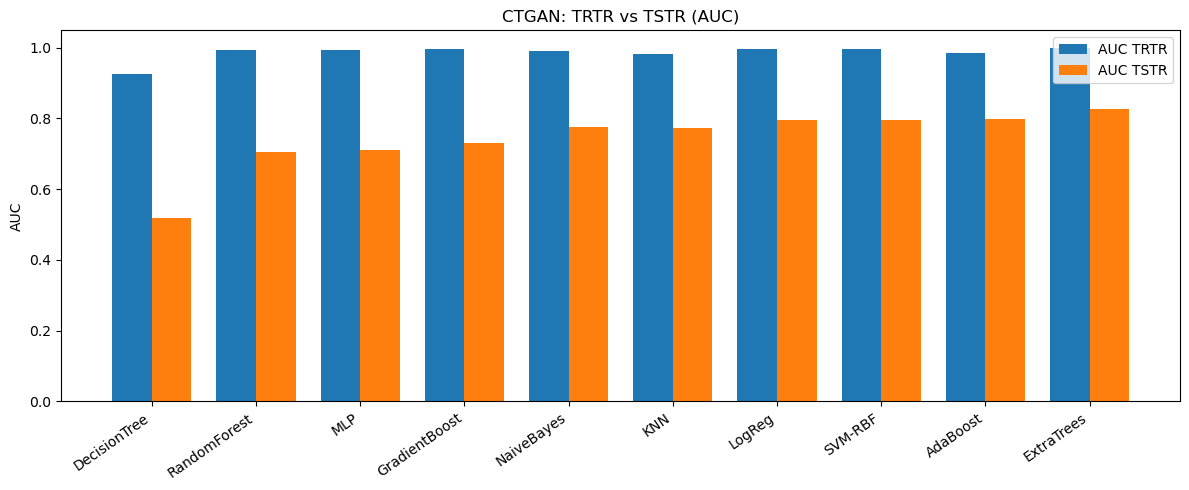

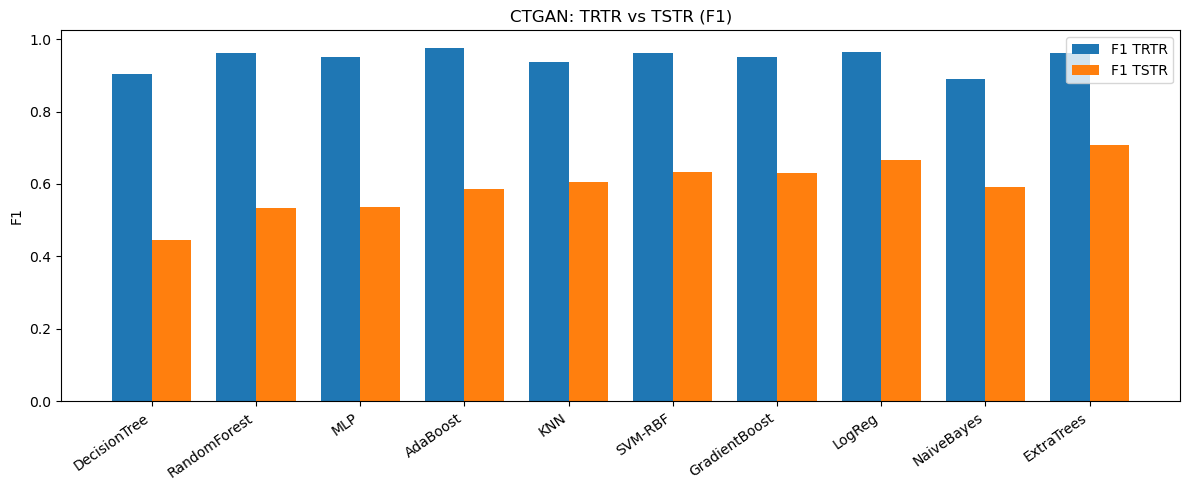

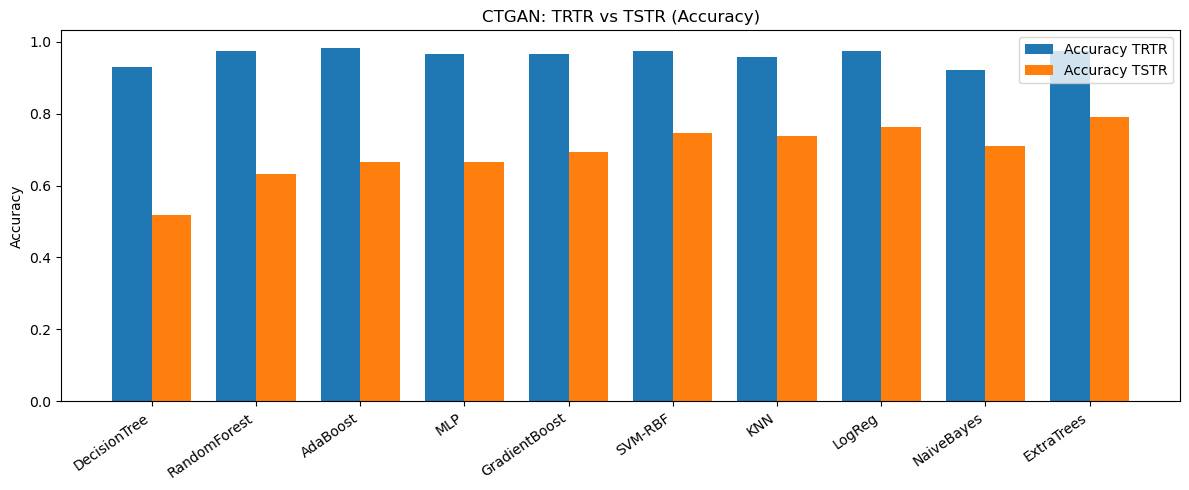

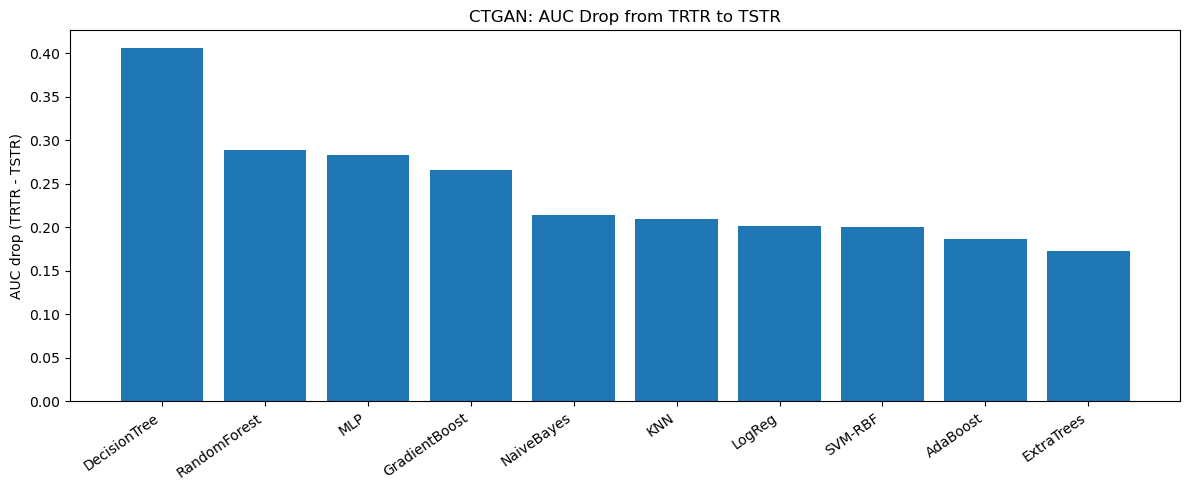


CopulaGAN - TSTR


,Model,Accuracy,F1,AUC
9,MLP,0.859649,0.833333,0.949405
1,SVM-RBF,0.807018,0.784314,0.948413
0,LogReg,0.824561,0.800000,0.944775
6,ExtraTrees,0.745614,0.733945,0.922619
3,NaiveBayes,0.815789,0.787879,0.905093
7,GradientBoost,0.824561,0.795918,0.873347
5,RandomForest,0.771930,0.729167,0.851190
8,AdaBoost,0.754386,0.714286,0.843585
2,KNN,0.666667,0.688525,0.791832
4,DecisionTree,0.596491,0.439024,0.561508


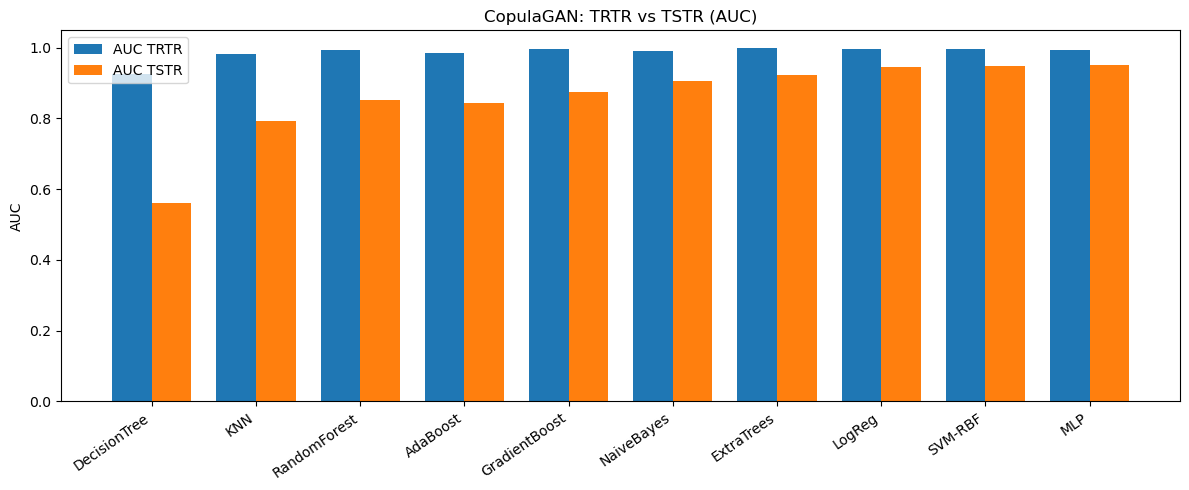

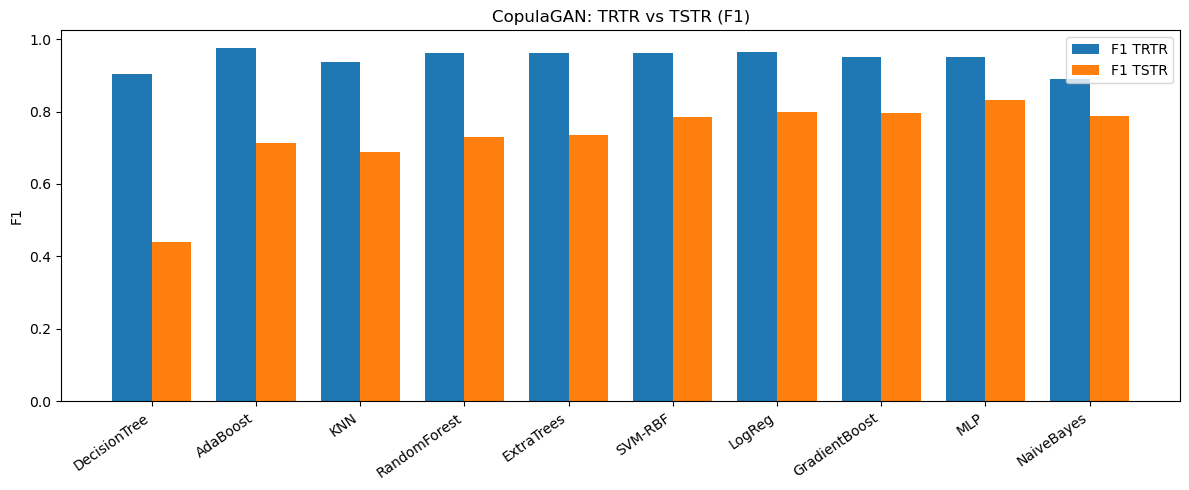

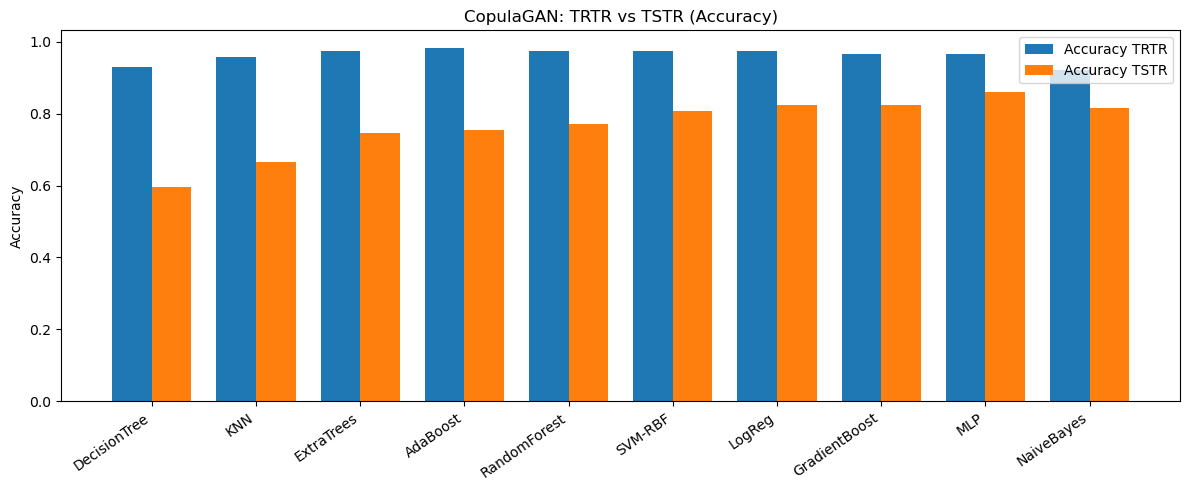

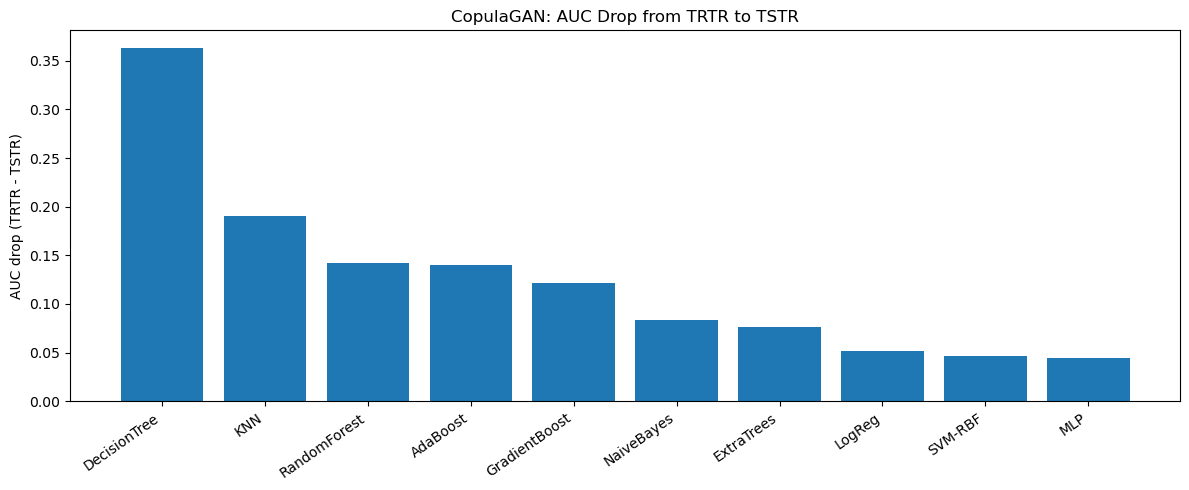


TVAE - TSTR


,Model,Accuracy,F1,AUC
8,AdaBoost,0.964912,0.954545,0.998016
5,RandomForest,0.982456,0.976744,0.997685
7,GradientBoost,0.964912,0.954545,0.997354
6,ExtraTrees,0.982456,0.976190,0.996362
9,MLP,0.956140,0.941176,0.996032
0,LogReg,0.973684,0.963855,0.992725
1,SVM-RBF,0.947368,0.930233,0.992394
3,NaiveBayes,0.921053,0.896552,0.985119
2,KNN,0.938596,0.911392,0.954200
4,DecisionTree,0.903509,0.873563,0.903770


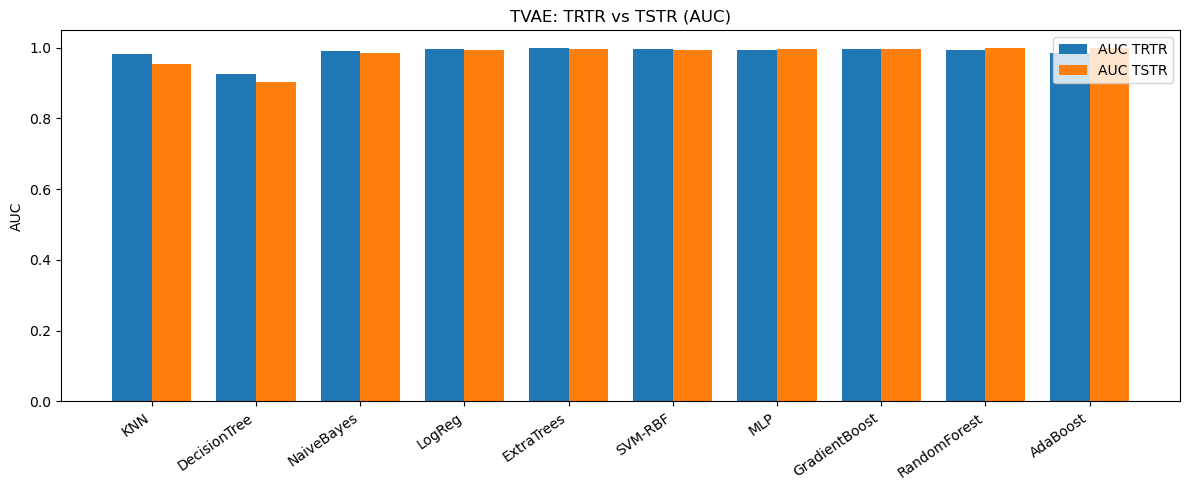

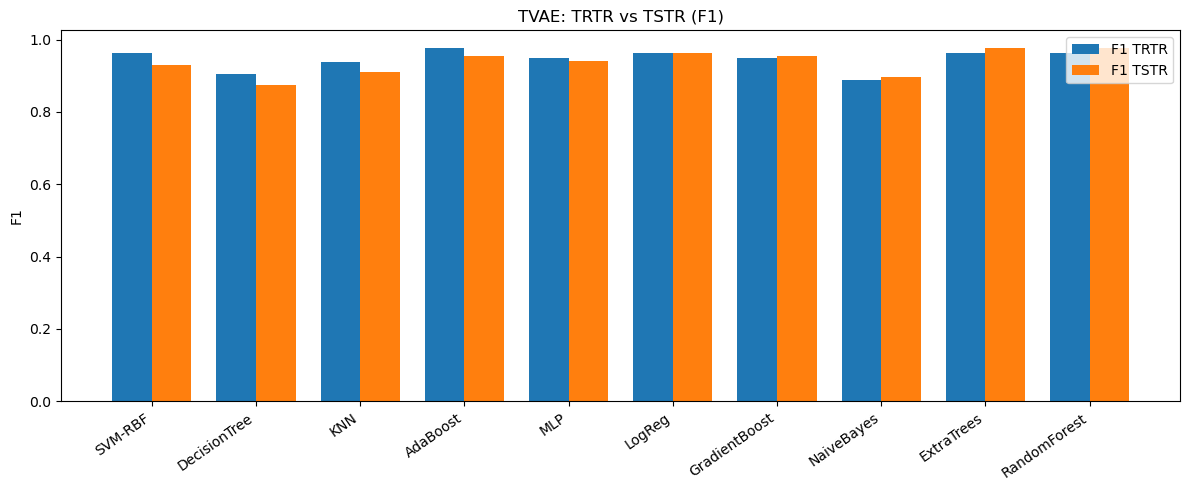

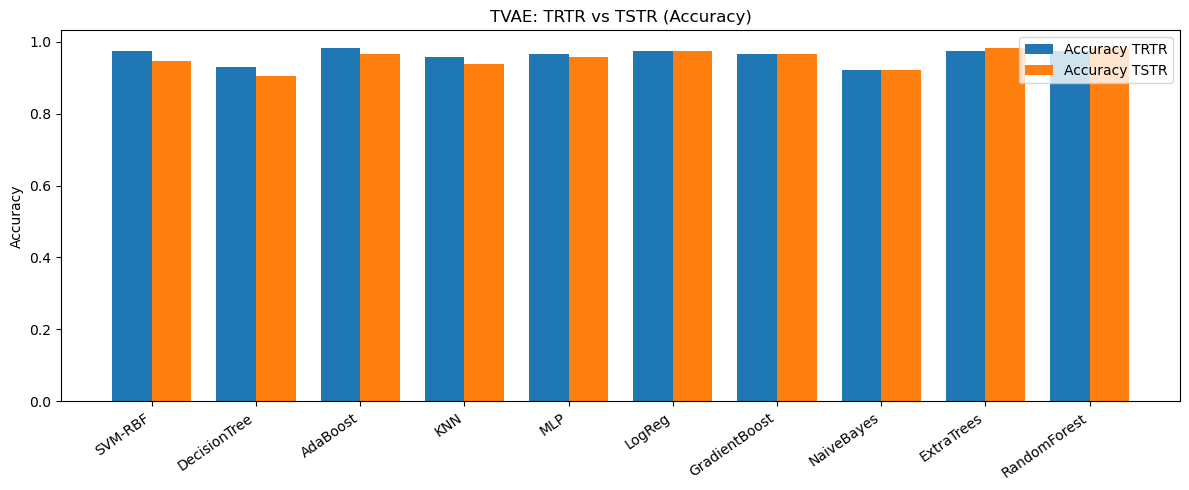

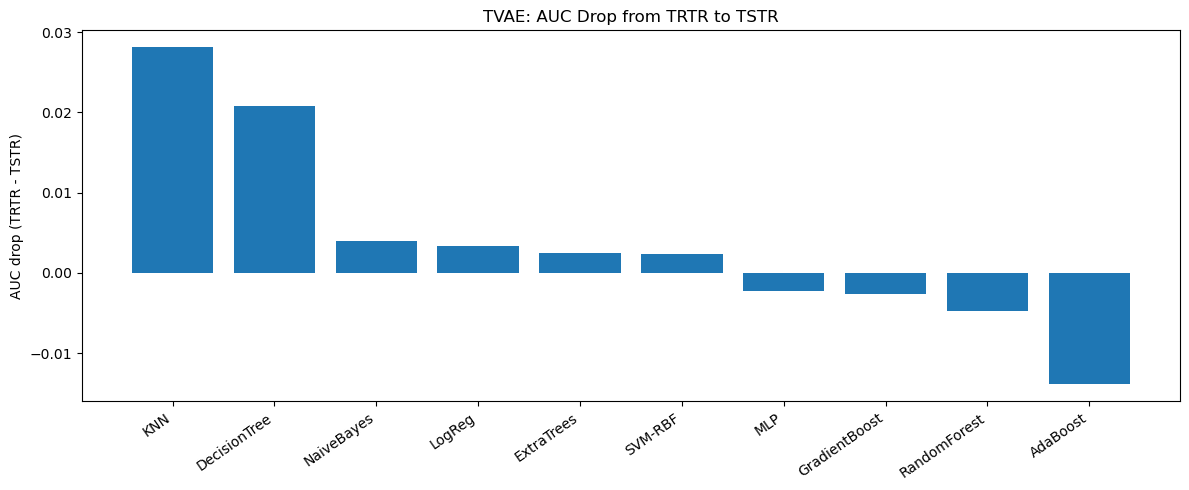


GaussianCopula - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.868421,0.782609,0.983796
3,NaiveBayes,0.885965,0.826667,0.980489
6,ExtraTrees,0.912281,0.864865,0.977017
1,SVM-RBF,0.877193,0.800000,0.967593
5,RandomForest,0.894737,0.833333,0.966270
8,AdaBoost,0.894737,0.837838,0.959491
7,GradientBoost,0.877193,0.810811,0.958664
2,KNN,0.877193,0.810811,0.899140
9,MLP,0.710526,0.611765,0.816799
4,DecisionTree,0.754386,0.688889,0.750992


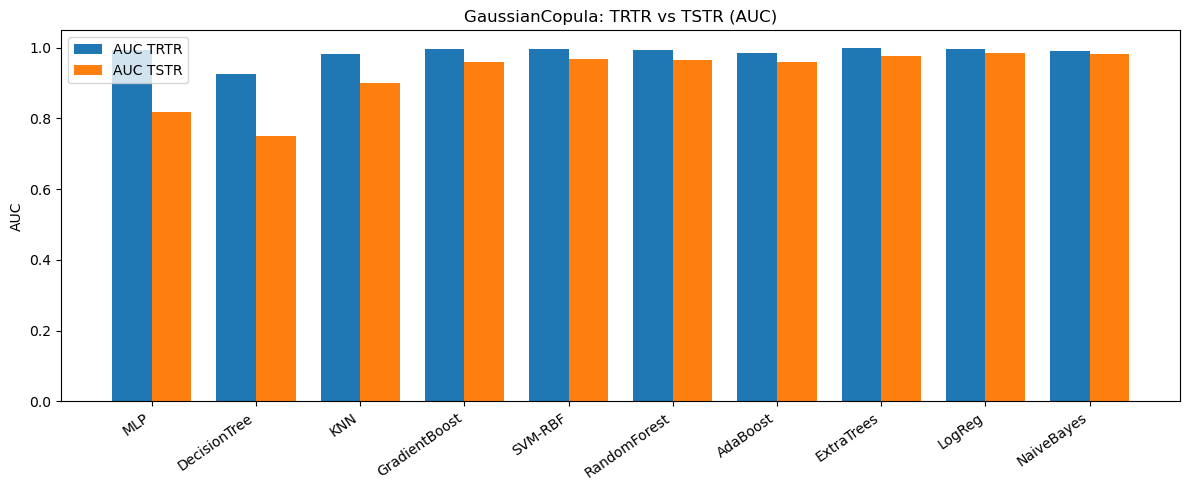

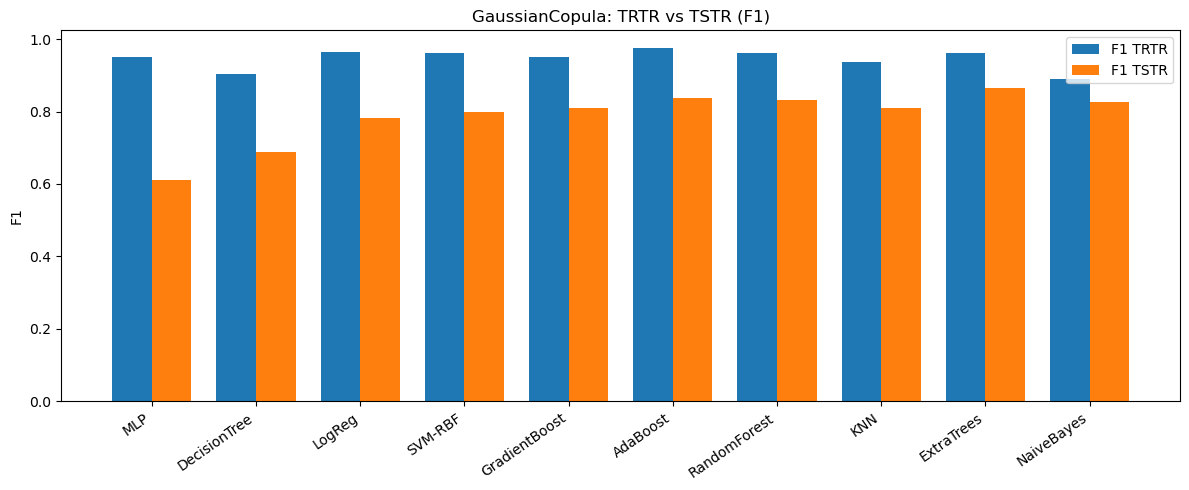

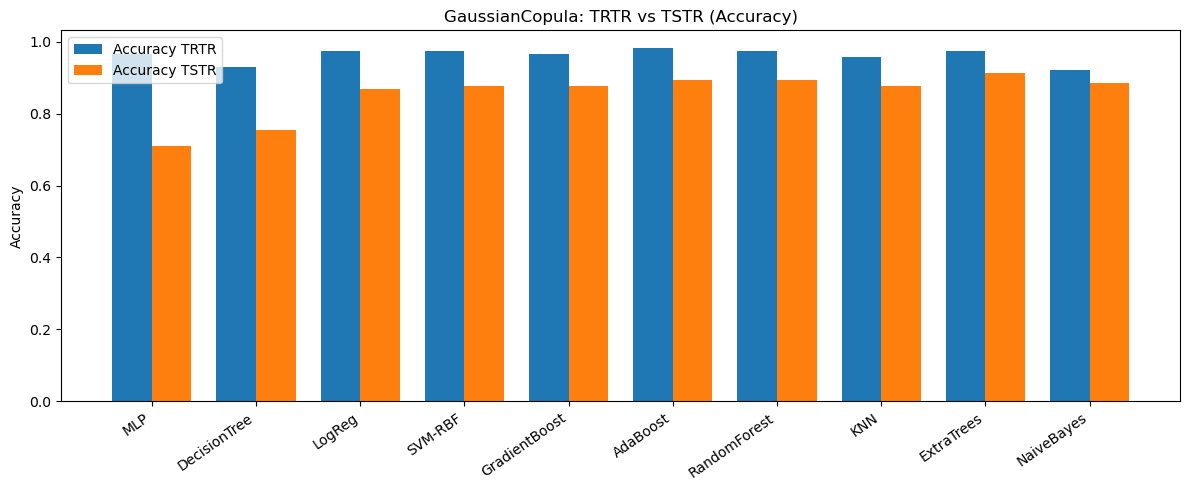

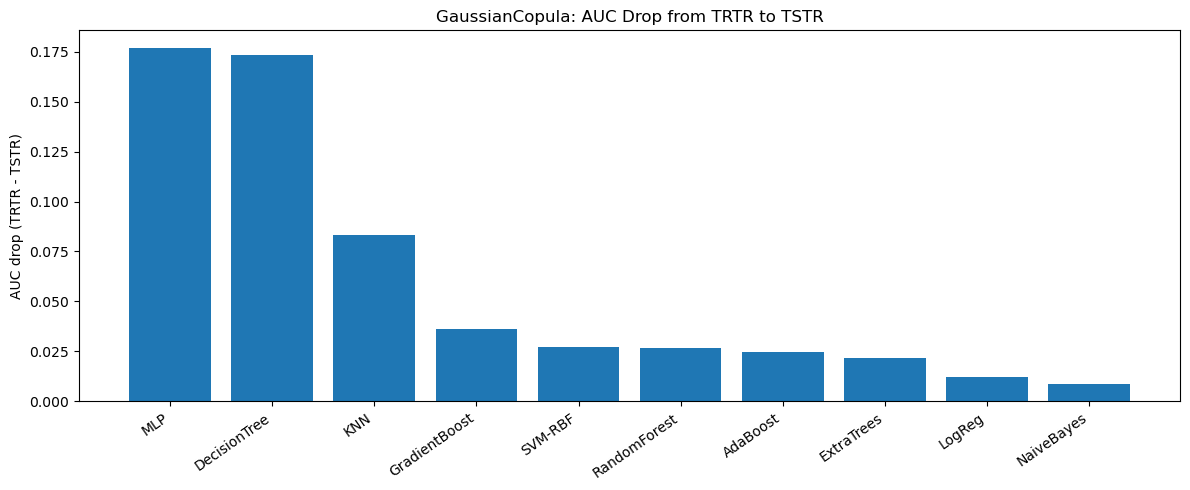


Average AUC drop by synthetic generator:


,Synthetic_Model,AUC_Drop
3,TVAE,0.003737
2,GaussianCopula,0.059077
1,CopulaGAN,0.125926
0,CTGAN,0.242675


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "diagnosis"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=cancer_data,
    test_df=cancer_data,
    label="diagnosis",
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=cancer_data,
        label="diagnosis",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
               .mean()
               .sort_values("AUC_Drop"))

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "diagnosis"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=cancer_data,
    test_df=cancer_data,
    label="diagnosis",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen],
        test_df=cancer_data,
        label="diagnosis",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,22.139785,16.473968,20.111976
1,CopulaGAN,43.617757,31.169478,46.802060
2,TVAE,9.333224,6.516332,24.693156
3,GaussianCopula,1.140859,0.892742,9.024199


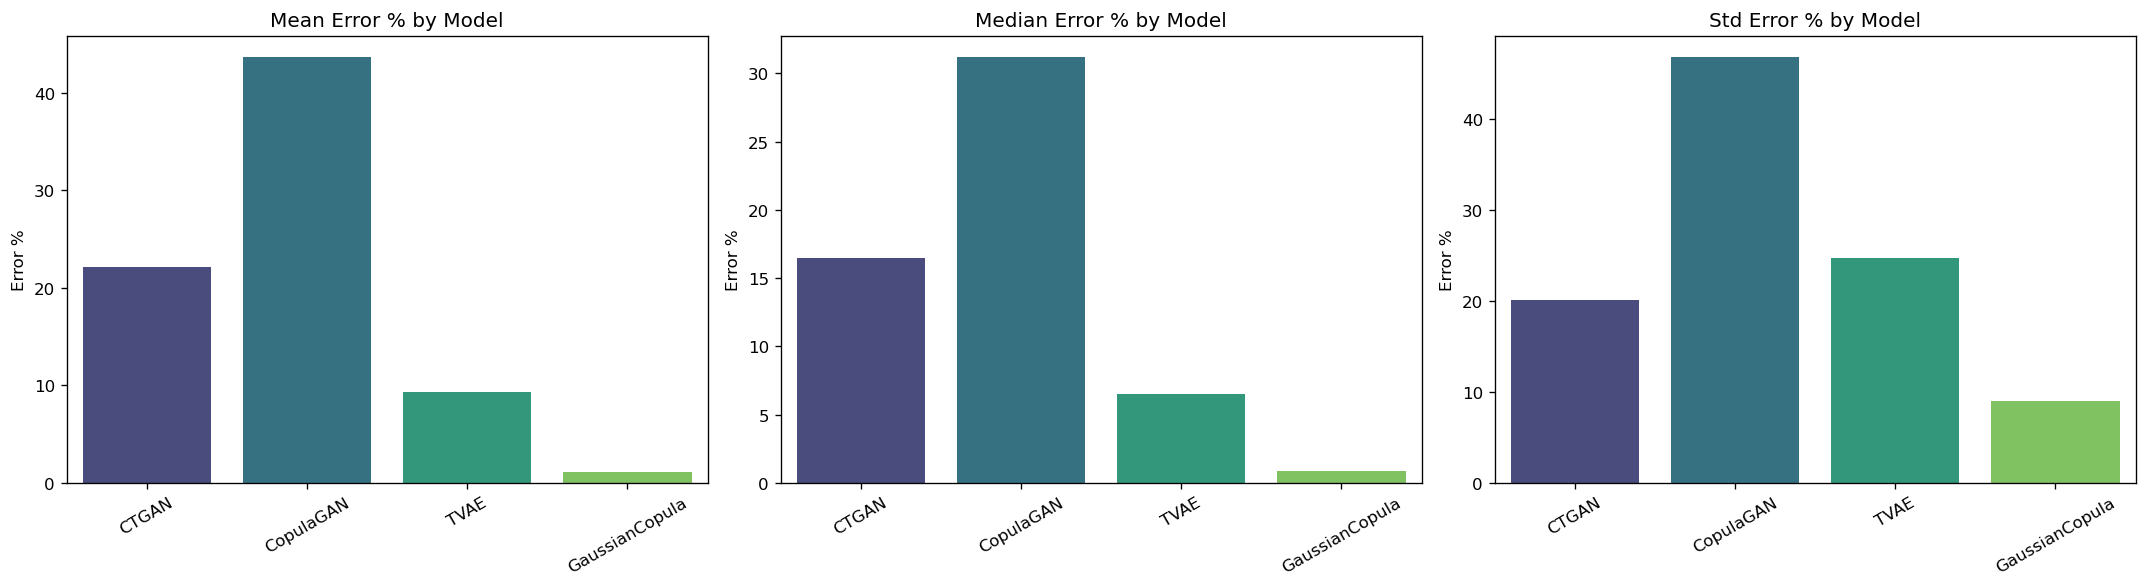

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = cancer_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "diagnosis" in num_cols:
    num_cols.remove("diagnosis")

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


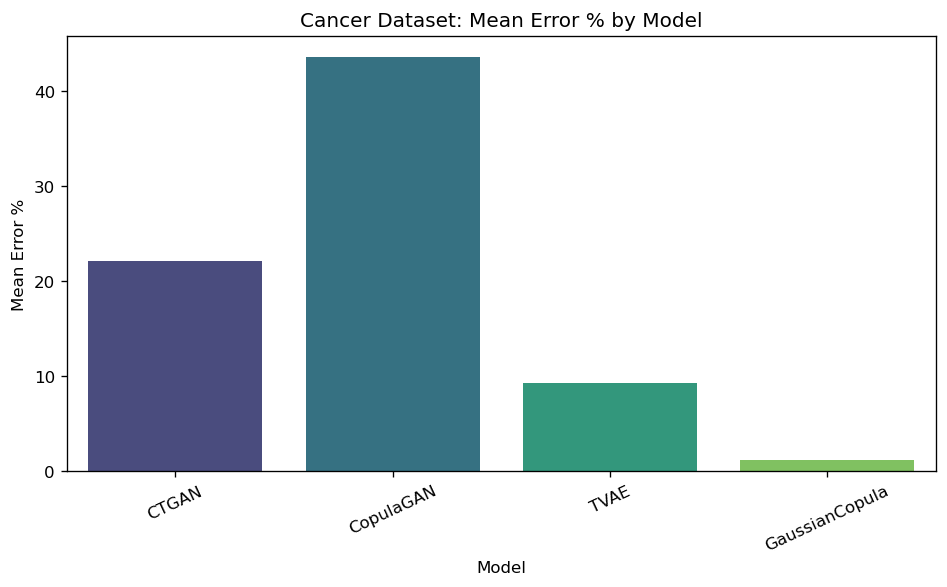

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Cancer Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

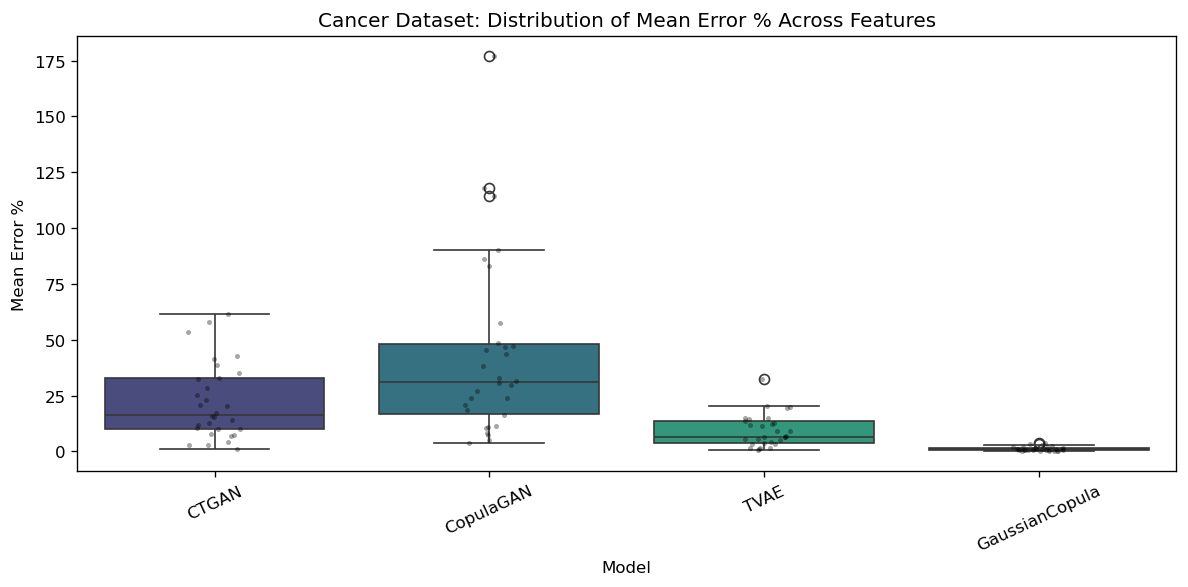

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Cancer Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

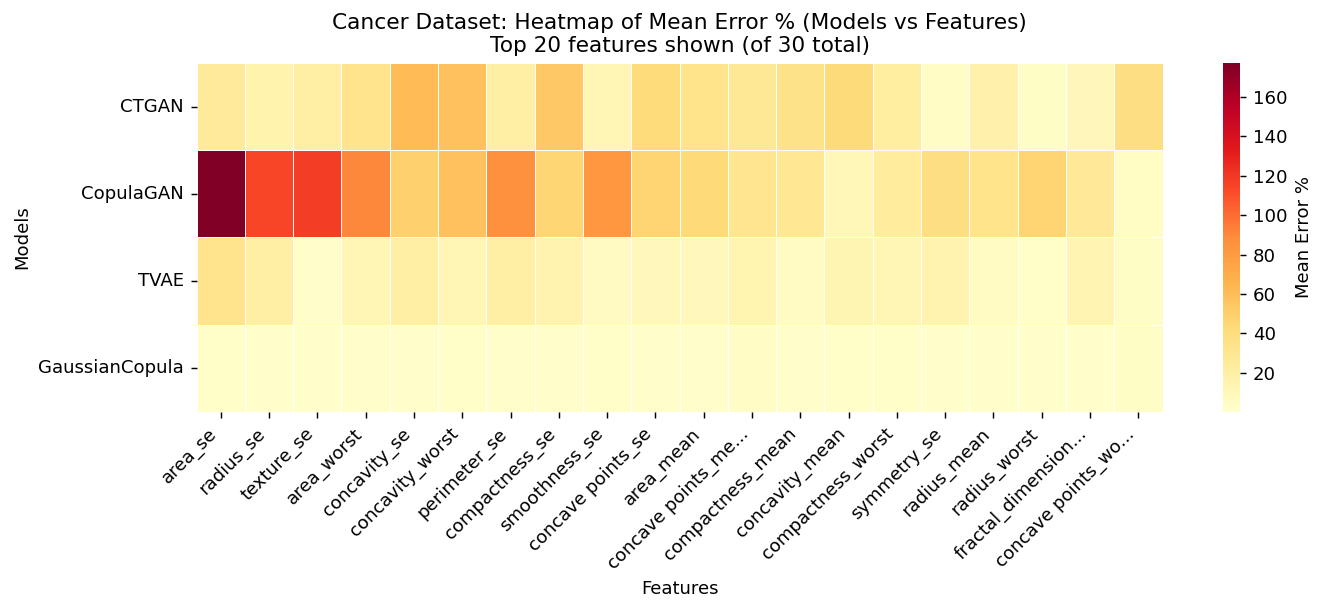

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Cancer Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

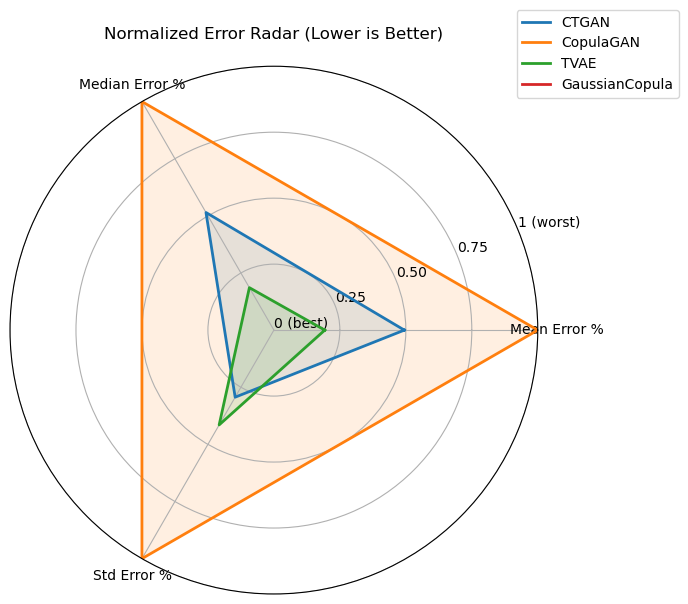

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,0.494361,0.514627,0.293499
1,CopulaGAN,1.000000,1.000000,1.000000
2,TVAE,0.192866,0.185740,0.414766
3,GaussianCopula,0.000000,0.000000,0.000000


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requires summary_df with columns:
# ["Model", "Mean Error %", "Median Error %", "Std Error %"]

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best / lowest error, 1 = worst / highest error)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,GaussianCopula,7.366667,7.0,19
1,CTGAN,16.900000,11.0,54
2,CopulaGAN,28.200000,25.0,75
3,TVAE,33.233333,16.0,124


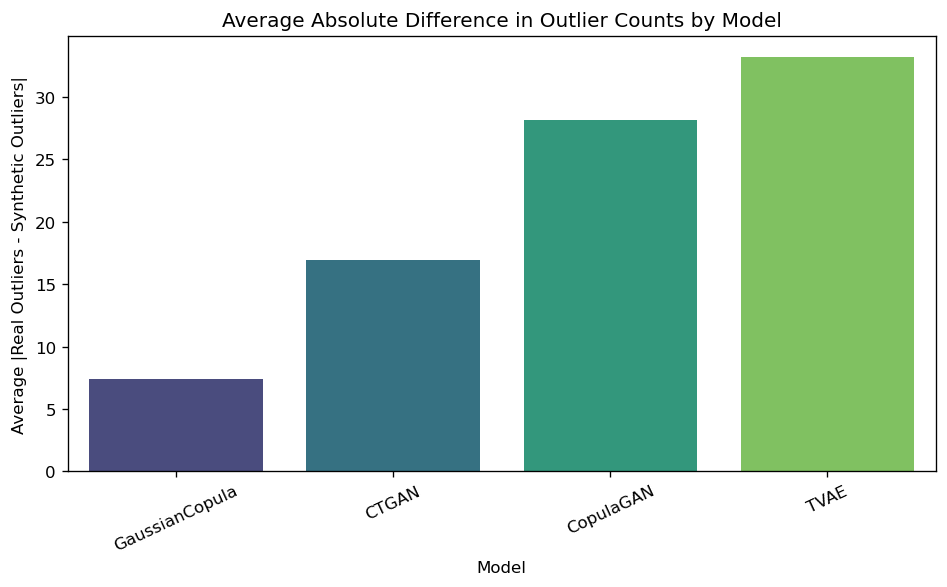

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumes:
# - cancer_data
# - synthetic_datasets = {"CTGAN": df, "CopulaGAN": df, "TVAE": df, "GaussianCopula": df}

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = cancer_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "diagnosis" in num_cols:
    num_cols.remove("diagnosis")

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [33]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(cancer_data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(cancer_data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(cancer_data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(cancer_data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(cancer_data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[cancer_data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = cancer_data.select_dtypes(include=[np.number]).columns
real_matrix = normalize_rows(cancer_data[num_cols].to_numpy())

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy())
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.973061  0.968179  0.991626  0.770124  0.986789  0.998017  0.970124   
R2   0.995636  0.953860  0.968706  0.850006  0.999431  0.992677  0.993034   
R3   0.996553  0.953203  0.964041  0.858547  0.999222  0.990794  0.994664   
R4   0.988636  0.972192  0.963797  0.844076  0.995223  0.992084  0.990962   
R5   0.998896  0.938920  0.941462  0.894307  0.996050  0.978375  0.997615   
R6   0.989880  0.970127  0.972545  0.834019  0.997355  0.995935  0.990302   
R7   0.993177  0.960269  0.973601  0.838399  0.998987  0.995384  0.991025   
R8   0.990798  0.967251  0.972947  0.835050  0.997680  0.995855  0.990709   
R9   0.993342  0.964547  0.962508  0.855222  0.997983  0.991496  0.994284   
R10  0.991222  0.967326  0.968139  0.842982  0.997658  0.993940  0.992378   

           S8        S9       S10  
R1   0.676553  0.995170  0.983882  
R2   0.769905  0.981338  0.954

,avg_cosine,max_cosine
CTGAN,0.944341,0.999941
CopulaGAN,0.939147,0.999928
TVAE,0.984730,0.999986
GaussianCopula,0.994264,0.999997


In [34]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = cancer_data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


CTGAN - Top 10 Real -> Synthetic Matchings
01. R158 -> S460   cosine similarity = 0.9999
02. R92 -> S312   cosine similarity = 0.9999
03. R440 -> S312   cosine similarity = 0.9999
04. R262 -> S565   cosine similarity = 0.9999
05. R480 -> S460   cosine similarity = 0.9999
06. R178 -> S460   cosine similarity = 0.9999
07. R373 -> S323   cosine similarity = 0.9999
08. R14 -> S312   cosine similarity = 0.9999
09. R87 -> S186   cosine similarity = 0.9999
10. R512 -> S312   cosine similarity = 0.9999

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R45 -> S476   cosine similarity = 0.9999
02. R241 -> S259   cosine similarity = 0.9999
03. R41 -> S476   cosine similarity = 0.9999
04. R27 -> S476   cosine similarity = 0.9999
05. R66 -> S501   cosine similarity = 0.9999
06. R450 -> S502   cosine similarity = 0.9999
07. R181 -> S502   cosine similarity = 0.9999
08. R260 -> S501   cosine similarity = 0.9999
09. R2 -> S502   cosine similarity = 0.9999
10. R482 -> S501   cosine similarity = 0.99

In [35]:
# Hungarian Mapping

import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = cancer_data.copy()

model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN": CTGANSynthesizer,
    "CopulaGAN": CopulaGANSynthesizer,
    "TVAE": TVAESynthesizer,
}

models = {}
synthetic_tables = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(real_df)
    models[name] = model
    synthetic_tables[name] = model.sample(num_rows=len(real_df))[real_df.columns]

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9996

R302 <-> S333   cosine similarity = 1.0000
R499 <-> S224   cosine similarity = 1.0000
R165 <-> S545   cosine similarity = 1.0000
R33 <-> S457   cosine similarity = 1.0000
R30 <-> S569   cosine similarity = 1.0000
R82 <-> S7   cosine similarity = 1.0000
R370 <-> S567   cosine similarity = 1.0000
R534 <-> S483   cosine similarity = 1.0000
R132 <-> S26   cosine similarity = 1.0000
R530 <-> S269   cosine similarity = 1.0000

CTGAN: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9476

R342 <-> S337   cosine similarity = 0.9987
R67 <-> S259   cosine similarity = 0.9980
R56 <-> S167   cosine similarity = 0.9978
R156 <-> S237   cosine similarity = 0.9972
R305 <-> S500   cosine similarity = 0.9968
R5 <-> S222   cosine similarity = 0.9967
R245 <-> S5

In [36]:
%pip install xlsxwriter 

Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd
import numpy as np

real_df = cancer_data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            continue
        if model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Hungarian_Matchings_All_Models.xlsx


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
3,GaussianCopula,569,0.999626,0.999786,0.993055,0.999990
2,TVAE,569,0.994255,0.997720,0.876007,0.999955
1,CopulaGAN,569,0.956947,0.974895,0.790947,0.999090
0,CTGAN,569,0.947580,0.960161,0.752606,0.998688


# 7. Mahalanobis distance with Hungrain Mapping  

In [38]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

data_numeric = cancer_data.select_dtypes(include=[np.number]).dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (31,), Inv_cov shape: (31, 31)


In [39]:
mahalanobis_results = {}
num_cols = cancer_data.select_dtypes(include=[np.number]).columns.tolist()

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=float)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
GaussianCopula,6.833884,6.586305,1.969295,3.102918,18.543961
TVAE,45.102377,34.759600,32.553191,10.038234,172.413379
CTGAN,112.085956,96.670589,56.891797,27.692581,351.687809
CopulaGAN,135.272535,122.626413,64.834342,26.091745,356.703815


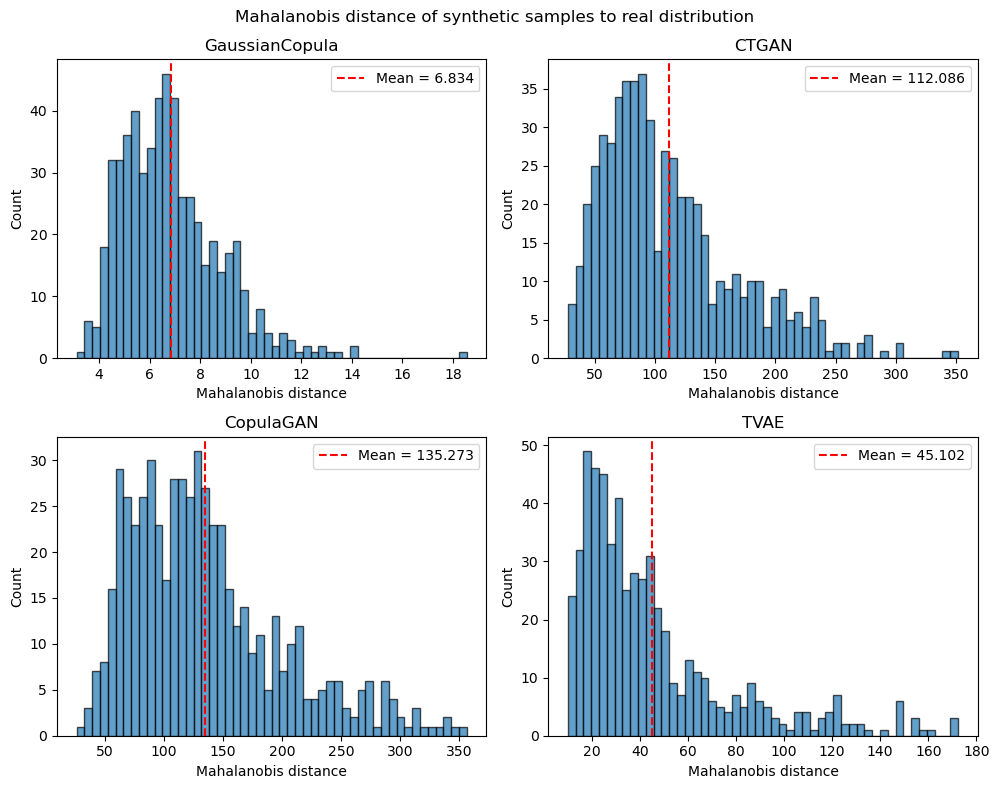

In [40]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [41]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = cancer_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = cancer_data[num_cols].to_numpy(dtype=float)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
GaussianCopula,6.265554,5.758909,2.263700,22.044746
TVAE,43.786276,33.531645,32.536020,170.343945
CTGAN,110.561526,94.470103,57.147459,350.595798
CopulaGAN,133.996058,121.743255,65.134678,355.799781


In [42]:
# Greedy mapping 

import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = cancer_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = cancer_data[num_cols].to_numpy(dtype=float)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    total_g, mean_g, _ = greedy_one_to_one_matching(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Greedy total": total_g,
        "Hungarian total": h_total,
        "Greedy mean": mean_g,
        "Hungarian mean": h_mean,
        "Total diff (Greedy - Hungarian)": total_g - h_total,
        "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (Mahalanobis distance):")
display(greedy_summary)

print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
GaussianCopula,3695.637350,6.494969
CTGAN,63080.200256,110.861512
CopulaGAN,76402.940834,134.275819
TVAE,25099.055718,44.110818



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
GaussianCopula,3695.637350,3565.100193,6.494969,6.265554,130.537157,0.229415
CTGAN,63080.200256,62909.508427,110.861512,110.561526,170.691829,0.299986
CopulaGAN,76402.940834,76243.757251,134.275819,133.996058,159.183583,0.279760
TVAE,25099.055718,24914.391157,44.110818,43.786276,184.664562,0.324542


In [43]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=float)
    S = synth_df[feature_cols].to_numpy(dtype=float)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=float), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = cancer_data.copy()

feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "diagnosis"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=float)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 30
GaussianCopula: avg matched Mahalanobis distance = 5.9931
CTGAN: avg matched Mahalanobis distance = 110.2922
CopulaGAN: avg matched Mahalanobis distance = 133.7379
TVAE: avg matched Mahalanobis distance = 43.6827


In [44]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in cancer_data.select_dtypes(include=[np.number]).columns if c != "diagnosis"]
real_df = cancer_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
hungarian_results = {}

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    hungarian_results[model_name] = {"row_ind": row_ind, "col_ind": col_ind, "dists": dists}

    order = np.argsort(dists)
    top_k = min(20, len(order))

    print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
    for rank, k in enumerate(order[:top_k], 1):
        print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")


CTGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R60 -> S491   distance = 25.3363
02. R507 -> S312   distance = 26.4528
03. R38 -> S150   distance = 26.5475
04. R30 -> S186   distance = 28.2420
05. R450 -> S1   distance = 29.5384
06. R502 -> S421   distance = 29.9880
07. R501 -> S56   distance = 31.3804
08. R337 -> S323   distance = 32.4787
09. R152 -> S248   distance = 32.8189
10. R436 -> S535   distance = 33.2756
11. R409 -> S359   distance = 33.9002
12. R102 -> S469   distance = 34.1211
13. R359 -> S106   distance = 34.1590
14. R181 -> S549   distance = 35.2464
15. R104 -> S78   distance = 36.3130
16. R18 -> S431   distance = 36.3824
17. R307 -> S241   distance = 36.7216
18. R48 -> S310   distance = 36.7863
19. R8 -> S91   distance = 37.4087
20. R531 -> S456   distance = 37.9272

CopulaGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R432 -> S82   distance = 24.7739
02. R411 -> S113   distance = 29.6399
03. R529 -> S467   distance = 33.5155
0

In [45]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in cancer_data.select_dtypes(include=[np.number]).columns if c != "diagnosis"]
real_df = cancer_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S161   distance = 105.8185
R2 -> S449   distance = 51.6207
R3 -> S152   distance = 40.0965
R4 -> S68   distance = 70.1803
R5 -> S47   distance = 146.1345
R6 -> S528   distance = 69.6347
R7 -> S244   distance = 106.8294
R8 -> S91   distance = 37.4087
R9 -> S274   distance = 164.2236
R10 -> S14   distance = 38.8619
R11 -> S30   distance = 136.7928
R12 -> S510   distance = 203.9991
R13 -> S231   distance = 51.6937
R14 -> S29   distance = 86.2026
R15 -> S363   distance = 45.3373
R16 -> S462   distance = 119.1690
R17 -> S513   distance = 106.9214
R18 -> S431   distance = 36.3824
R19 -> S302   distance = 75.2711
R20 -> S500   distance = 218.7411

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S278   distance = 123.5870
R2 -> S266   distance = 138.2646
R3 -> S151   distance = 98.8084
R4 -> S232   distance = 57.3640
R5 -> S327   distance = 246.3297
R6 -> S200   distance = 161.1988
R7 -> S163   distance = 94.9412
R8 -> S108   distance = 211.

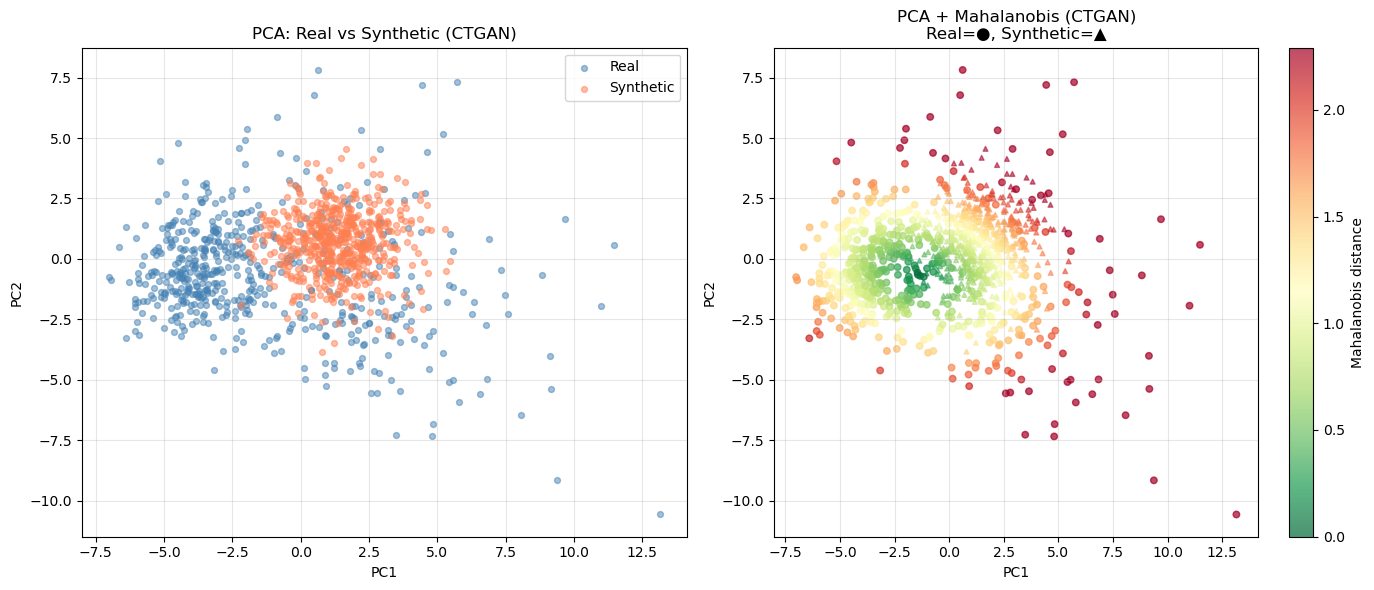

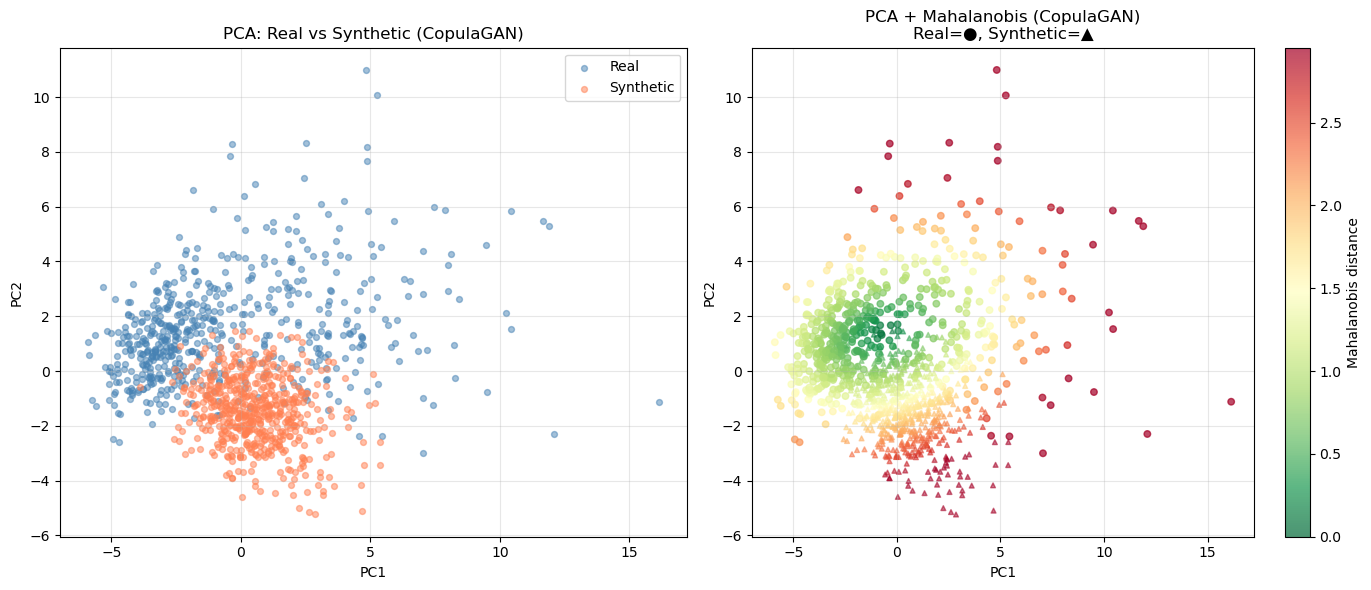

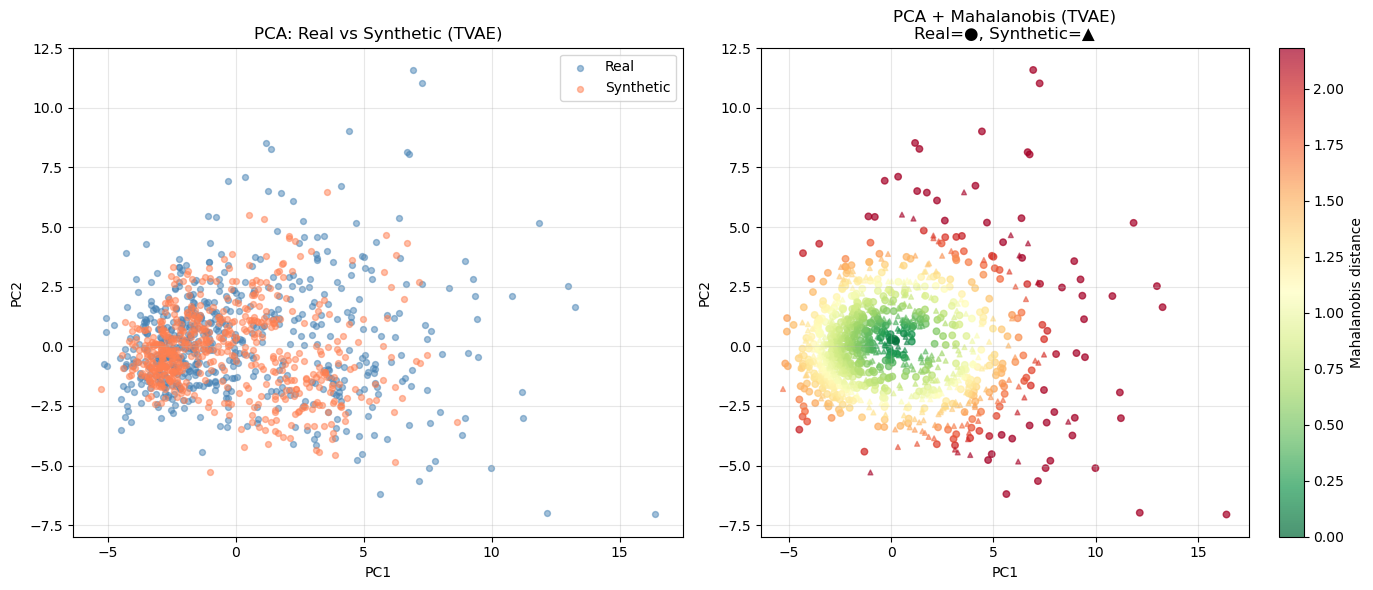

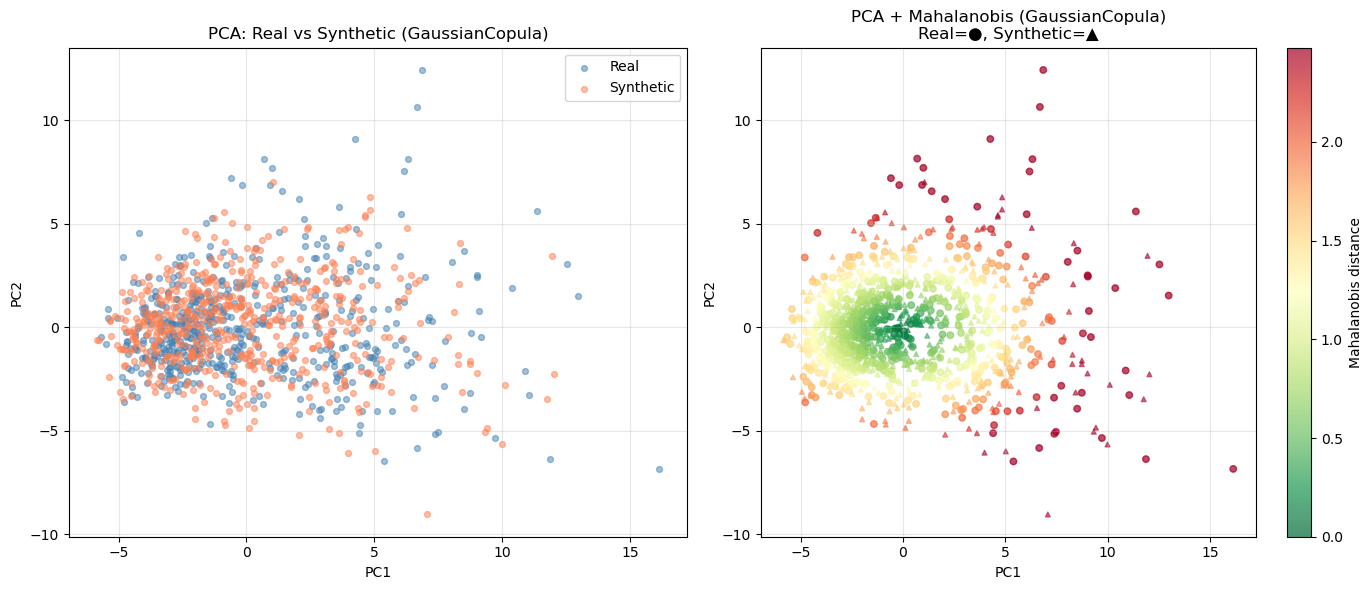

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
2,TVAE,1.210580,0.982851,-0.227729
3,GaussianCopula,1.207462,1.170214,-0.037248
0,CTGAN,1.220098,1.205707,-0.014391
1,CopulaGAN,1.215372,1.783988,0.568616


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = cancer_data.copy()
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "diagnosis"]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)

In [47]:
# print results on excel sheets 

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            matched_df.to_excel(writer, sheet_name=model_name[:31], index=False)

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
real_df = cancer_data.copy()
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "diagnosis"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [48]:
# MIA with ML regression model 

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "diagnosis"
feature_cols = [c for c in cancer_data.select_dtypes(include=[np.number]).columns if c != target_col]

real_df = cancer_data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=float)
y_train = real_df[target_col].to_numpy(dtype=int)

X_test = synth_df[feature_cols].to_numpy(dtype=float)
y_test = synth_df[target_col].to_numpy(dtype=int)

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.6348973471171636, 'Advantage': 0.27768014059753965, 'TPR_at_FPR_001': 0.012302284710017574}


In [49]:
# MIA with Mahalanobis 

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in cancer_data.select_dtypes(include=[np.number]).columns if c != "diagnosis"]
X_train = cancer_data[feature_cols].to_numpy(dtype=float)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTGAN,1.000000,1.000000,1.000000,4.952784,112.915275
1,CopulaGAN,1.000000,1.000000,1.000000,4.952784,136.272814
2,TVAE,0.998391,0.966608,0.973638,4.952784,45.431532
3,GaussianCopula,0.792606,0.493849,0.335677,4.952784,6.801795
